# Breast Cancer Wisconsin - Binary Classification Pipeline
**Course:** Applied Machine Learning Basic  
**Student:** Mahan Balooei  
**Dataset:** Breast Cancer Wisconsin Diagnostic (WDBC), UCI Machine Learning Repository

## Dataset

The **Breast Cancer Wisconsin Diagnostic (WDBC)** dataset contains 569 samples. Each sample represents measurements extracted from a digitized fine needle aspirate (FNA) image of a breast mass. The raw UCI file contains a patient `id`, the target `diagnosis`, and 30 numeric morphology features. The 30 features are organized into three measurement groups: `_mean`, `_se`, and `_worst`. These summaries are computed for 10 nuclear properties: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension.

The prediction task is **binary classification**: classify each case as **Malignant (M)** or **Benign (B)**.

## Evaluation Framing

This notebook treats **malignant tumors as the positive class** (`M = 1`) because missing a malignant case is the highest-cost error in a diagnostic-support setting. The main optimization metric used for cross-validation and hyperparameter tuning is **F1-score on the malignant class**, because it balances malignant recall with precision.

The held-out test set is used for final internal assessment, not for hyperparameter search. Therefore, the final model choice considers training-set cross-validation performance, practical differences between models, interpretability, and the test-set error profile reported after fitting. In the final comparison, malignant recall and the exact **false-negative count** are reported explicitly because two models with similar F1 or accuracy may still differ in the number of missed malignant cases.

**Note:** This is an educational machine-learning project, not a clinical deployment study. The dataset is small and internally validated only; no model here should be interpreted as ready for medical use.


## 1. Setup and imports

This first cell prepares the notebook. I import pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and scikit-learn tools for preprocessing, model training, hyperparameter tuning, and model evaluation.

I also define one `RANDOM_STATE` value and reuse it throughout the notebook. This makes train/test splitting, cross-validation shuffling, and stochastic model behaviour reproducible.


In [305]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_breast_cancer

# Single source of truth for all stochastic components
RANDOM_STATE = 42

# Consistent visual style throughout
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful. RANDOM_STATE =', RANDOM_STATE)

All imports successful. RANDOM_STATE = 42


## 2. Loading the dataset

The notebook first tries to load the raw `wdbc.data` file from the UCI Machine Learning Repository. The raw file has no header row, so the expected column names are assigned manually. If the URL is unavailable, the notebook falls back to scikit-learn's bundled copy of the same WDBC dataset so that the analysis remains reproducible offline.

The raw dataset contains:
- an `id` column,
- a `diagnosis` target column,
- 30 continuous numeric features describing cell-nuclei morphology.

The `id` column is kept during the first inspection and removed before modelling.


In [306]:
# Load the Breast Cancer Wisconsin Diagnostic dataset
# Primary source: raw UCI file
# Fallback: scikit-learn's bundled WDBC copy
import urllib.request

uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'

feature_columns = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

columns = ['id', 'diagnosis'] + feature_columns

try:
    with urllib.request.urlopen(uci_url, timeout=3) as response:
        df = pd.read_csv(response, header=None, names=columns)
    data_source = 'UCI raw wdbc.data file'
except Exception as err:
    sklearn_data = load_breast_cancer()
    df = pd.DataFrame(sklearn_data.data, columns=feature_columns)
    # In scikit-learn: target 0 = malignant, target 1 = benign
    df.insert(0, 'diagnosis', np.where(sklearn_data.target == 0, 'M', 'B'))
    # The bundled version does not include UCI patient IDs; create placeholders because id is dropped later
    df.insert(0, 'id', np.arange(1, len(df) + 1))
    data_source = 'scikit-learn bundled WDBC copy'
    print('UCI URL unavailable; using fallback dataset. Reason:', type(err).__name__)

print('Data source:', data_source)
print('Shape:', df.shape)
print('Total missing values:', int(df.isna().sum().sum()))
print()
df.info()
df.head()

Data source: UCI raw wdbc.data file
Shape: (569, 32)
Total missing values: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  te

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Inspection findings:** The DataFrame has 569 rows and 32 columns. Of those 32:
- `id` is an identifier and is not a tumor morphology measurement.
- `diagnosis` is the target (`M`/`B`) before encoding.
- The remaining 30 columns are continuous numeric features.
- The dataset inspection reports **0 missing values**, so imputation is not included. Adding an imputer would not solve an observed data problem in this dataset and would make the pipeline unnecessarily complex.


### 2.2 Duplicate Detection

Duplicates are checked before train/test splitting. I check both exact full-row duplicates and duplicates after excluding `id`, because two rows with different identifiers but identical measurements and labels would still be suspicious from a modelling perspective.


In [307]:
# Check for exact duplicates before any splitting to prevent leakage
n_dupes_full = df.duplicated().sum()
n_dupes_without_id = df.drop(columns=['id'], errors='ignore').duplicated().sum()

print(f'Exact duplicate rows including id: {n_dupes_full}')
print(f'Duplicate rows after excluding id: {n_dupes_without_id}')

Exact duplicate rows including id: 0
Duplicate rows after excluding id: 0


**Interpretation:** Both duplicate checks return 0. No deduplication is required. If duplicates had been found, they would need to be removed **before** splitting; otherwise, near-identical information could appear in both train and test sets and inflate the reported generalisation score.


### 2.3 Drop Uninformative Columns

The `id` column is dropped before any modelling because it is a patient identifier, not a tumor morphology measurement. Including it would risk the model learning a spurious identifier-based pattern that cannot generalize to new patients.


In [308]:
# Drop non-predictive identifier before modelling
# errors='ignore' keeps this cell robust if the dataset has already been cleaned
df = df.drop(columns=['id'], errors='ignore')
print('Remaining columns:', df.shape[1])
print(df.columns.tolist())

Remaining columns: 31
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


### 2.4 Encode the Target

The `diagnosis` column contains string labels. We remap them to integers: **M → 1** (malignant, the positive/high-priority class) and **B → 0** (benign, negative class). This convention aligns with scikit-learn's default behaviour of treating class 1 as the positive class in binary metrics like precision, recall, and F1.

In [309]:
# Encode M=1 (malignant/positive), B=0 (benign/negative) - consistent with the diagnostic-support positive class
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

y_counts = df['diagnosis'].value_counts()
y_pct = df['diagnosis'].value_counts(normalize=True) * 100
print('Class counts:')
print(pd.DataFrame({'count': y_counts, 'pct': y_pct.round(1)}))

Class counts:
           count   pct
diagnosis             
0            357  62.7
1            212  37.3


**Class distribution: 357 Benign (62.7%) and 212 Malignant (37.3%).** This is a **moderate class imbalance**, not an extreme rare-event setting. It still affects the evaluation strategy in three concrete ways:

1. **Use stratified splitting.** The train/test split and cross-validation folds should preserve the 62.7/37.3 class ratio.
2. **Do not rely on accuracy alone.** A classifier that always predicts benign reaches 62.7% accuracy but detects 0 malignant cases.
3. **Optimize F1 for the malignant class and inspect recall/FN count.** F1 prevents a model from improving recall by flagging almost everything as malignant, while the confusion matrix shows whether malignant cases are actually being missed.


## 3. First look at the data and target variable

Section 2.4 already reported the exact class counts in a table. This section adds a visual representation for a different purpose: the pie chart communicates the 62.7/37.3 proportional split at a glance, while the bar chart makes the absolute count difference easier to judge than a table row. The two formats complement each other and are not redundant - the table is a precise reference, the charts are a communication aid for a reader scanning the notebook.

The target is encoded as:
- `0 = Benign`
- `1 = Malignant`

I treat malignant tumors as the positive class because, in this project framing, a false negative means a malignant case is incorrectly predicted as benign.


In [310]:
# checking the target distribution before modeling because class imbalance affects metric choice
target_counts = df['diagnosis'].value_counts().sort_index()
target_percentages = (df['diagnosis'].value_counts(normalize=True).sort_index() * 100).round(1)

target_distribution = pd.DataFrame({
    'Class label': ['Benign (0)', 'Malignant (1)'],
    'Count': [target_counts.loc[0], target_counts.loc[1]],
    'Percentage': [target_percentages.loc[0], target_percentages.loc[1]]
})

target_distribution

,Class label,Count,Percentage
0,Benign (0),357,62.7
1,Malignant (1),212,37.3


**Interpretation:** The dataset contains **357 benign cases (62.7%)** and **212 malignant cases (37.3%)**. This is a moderate imbalance: the malignant class is not extremely rare, but a model can still obtain a superficially acceptable accuracy by favoring the benign class. Therefore, later sections report not only accuracy, but also malignant precision, malignant recall, malignant F1-score, ROC-AUC, and exact confusion-matrix counts.


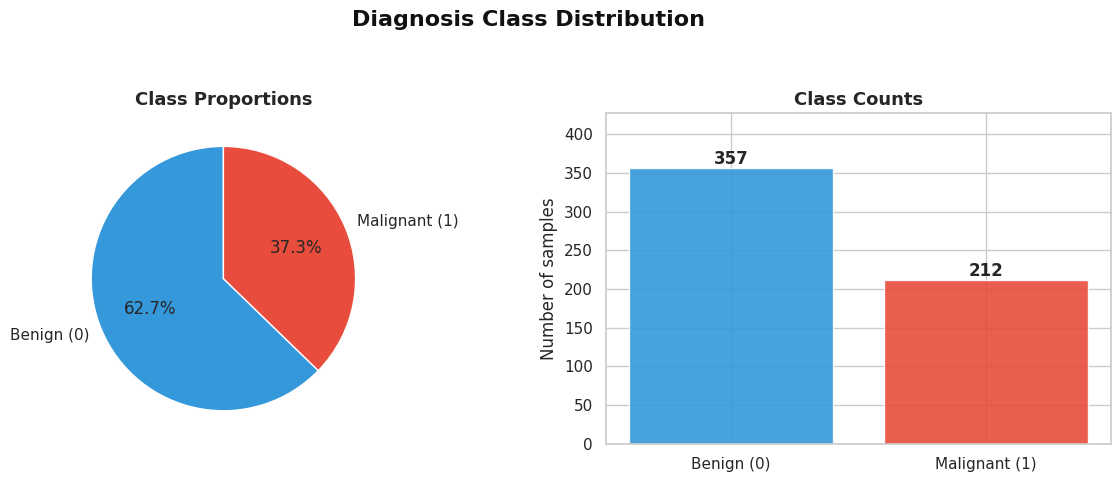

In [311]:
# visualizing the target distribution
# a pie chart for proportions and a bar chart for exact counts
colors = ['#3498DB', '#E74C3C']
labels = ['Benign (0)', 'Malignant (1)']

plt.figure(figsize=(12, 5))
plt.suptitle('Diagnosis Class Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie chart
plt.subplot(1, 2, 1)
plt.pie(target_counts.values, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
plt.title('Class Proportions', fontweight='bold', fontsize=13)

# Bar chart
plt.subplot(1, 2, 2)
bars = plt.bar(labels, target_counts.values, color=colors, edgecolor='white', alpha=0.9)
plt.title('Class Counts', fontweight='bold', fontsize=13)
plt.ylabel('Number of samples')

for bar, count in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha='center', fontweight='bold')

plt.ylim(0, max(target_counts.values) + 70)
plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

**Interpretation:** The bar chart confirms the exact class counts, while the pie chart shows the 62.7/37.3 split visually. The imbalance is large enough that a Dummy classifier predicting only benign would already achieve about 62.7% accuracy while detecting **zero** malignant cases. This is why malignant-class recall and F1-score are necessary evaluation metrics in this notebook.


## 4. Exploratory Data Analysis: numerical features

All 30 predictor columns are continuous numeric measurements. There are no categorical predictors that require category-count plots or one-hot encoding. Therefore, the EDA focuses on:

1. descriptive statistics and scale differences,
2. distribution shape and skewness,
3. class separation between benign and malignant samples,
4. multicollinearity between related morphology measurements,
5. feature-target relationships.

In [312]:
# Listing the 30 numeric predictor features
features = [c for c in df.columns if c != 'diagnosis']

print(f'Number of predictor features: {len(features)}')
print('All predictor dtypes:')
print(df[features].dtypes.value_counts())

Number of predictor features: 30
All predictor dtypes:
float64    30
Name: count, dtype: int64


### 4.1 Descriptive statistics

This table summarizes the 30 numeric predictors. It is useful before modelling because the features are measured on very different scales: for example, `area_worst` is in the hundreds or thousands, while `fractal_dimension_se` is close to zero. This directly justifies using `StandardScaler` for Logistic Regression, KNN, and SVM later.


In [313]:
# Descriptive statistics help identify scale differences, spread, and possible extreme values
df[features].describe().T.style.background_gradient(cmap='Greens').format('{:.4f}')

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
texture_mean,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
perimeter_mean,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
area_mean,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
smoothness_mean,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
compactness_mean,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
concavity_mean,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
concave points_mean,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
symmetry_mean,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
fractal_dimension_mean,569.0000,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


**Interpretation:** The features have very different numeric ranges. Area and perimeter features have large absolute values, while smoothness, compactness, concavity, symmetry, and fractal-dimension features are much smaller. This does not harm tree-based models, but it matters for scale-sensitive models such as Logistic Regression, KNN, and SVM. Scaling is therefore a dataset-driven preprocessing decision, not a generic cosmetic step.


### 4.2 Distribution shape, skewness, and kurtosis

To avoid informal distribution comments, I compute skewness and kurtosis directly. Positive skewness indicates a longer right tail, while kurtosis helps identify features with heavier tails or more extreme values than a normal-like reference shape.

In [314]:
# Quantify distribution shape so the written interpretation is grounded in actual values
# Kurtosis is included alongside skewness because both are referenced in the per-feature analysis below
distribution_summary = (
    df[features]
    .agg(['min', 'median', 'mean', 'std', 'skew',
          lambda x: x.kurt()])
    .rename(index={'<lambda>': 'kurtosis'})
    .T
)

most_right_skewed = distribution_summary.sort_values('skew', ascending=False).head(10)
most_symmetric = (
    distribution_summary
    .assign(abs_skew=lambda d: d['skew'].abs())
    .sort_values('abs_skew')
    .drop(columns='abs_skew')
    .head(10)
)

print('Ten most right-skewed features:')
display(most_right_skewed.round(4))

print('\nTen most symmetric features by absolute skewness:')
display(most_symmetric.round(4))

Ten most right-skewed features:


,min,median,mean,std,skew,kurtosis
area_se,6.8020,24.5300,40.3371,45.4910,5.4472,49.2091
concavity_se,0.0000,0.0259,0.0319,0.0302,5.1105,48.8614
fractal_dimension_se,0.0009,0.0032,0.0038,0.0026,3.9240,26.2808
perimeter_se,0.7570,2.2870,2.8661,2.0219,3.4436,21.4019
radius_se,0.1115,0.3242,0.4052,0.2773,3.0886,17.6867
smoothness_se,0.0017,0.0064,0.0070,0.0030,2.3145,10.4698
symmetry_se,0.0079,0.0187,0.0205,0.0083,2.1951,7.8961
compactness_se,0.0023,0.0204,0.0255,0.0179,1.9022,5.1063
area_worst,185.2000,686.5000,880.5831,569.3570,1.8594,4.3964
fractal_dimension_worst,0.0550,0.0800,0.0839,0.0181,1.6626,5.2446



Ten most symmetric features by absolute skewness:


,min,median,mean,std,skew,kurtosis
smoothness_worst,0.0712,0.1313,0.1324,0.0228,0.4154,0.5178
smoothness_mean,0.0526,0.0959,0.0964,0.0141,0.4563,0.8560
concave points_worst,0.0000,0.0999,0.1146,0.0657,0.4926,-0.5355
texture_worst,12.0200,25.4100,25.6772,6.1463,0.4983,0.2243
texture_mean,9.7100,18.8400,19.2896,4.3010,0.6504,0.7583
symmetry_mean,0.1060,0.1792,0.1812,0.0274,0.7256,1.2879
radius_mean,6.9810,13.3700,14.1273,3.5240,0.9424,0.8455
perimeter_mean,43.7900,86.2400,91.9690,24.2990,0.9907,0.9722
radius_worst,7.9300,14.9700,16.2692,4.8332,1.1031,0.9441
perimeter_worst,50.4100,97.6600,107.2612,33.6025,1.1282,1.0701


**Interpretation:** Several `_se` variables are strongly right-skewed, especially `area_se`, `concavity_se`, `fractal_dimension_se`, `perimeter_se`, and `radius_se`. Their skewness values are all above 3, with `area_se` and `concavity_se` above 5, so these distributions should not be described as approximately Gaussian. Since the `_se` features are standard-error summaries of the morphology measurements, most samples have relatively small values, while a smaller number of cases have much larger values. This right-tailed pattern is why the visual inspection is supported with numeric skewness values rather than relying only on informal comments from the histograms.

### 4.3 Compact view of all feature distributions by diagnosis

The following grid uses the **same plot type for every feature**: overlaid histograms split by diagnosis. This is deliberate. A consistent visualization strategy makes it easier to compare separation and overlap across all 30 numeric variables.


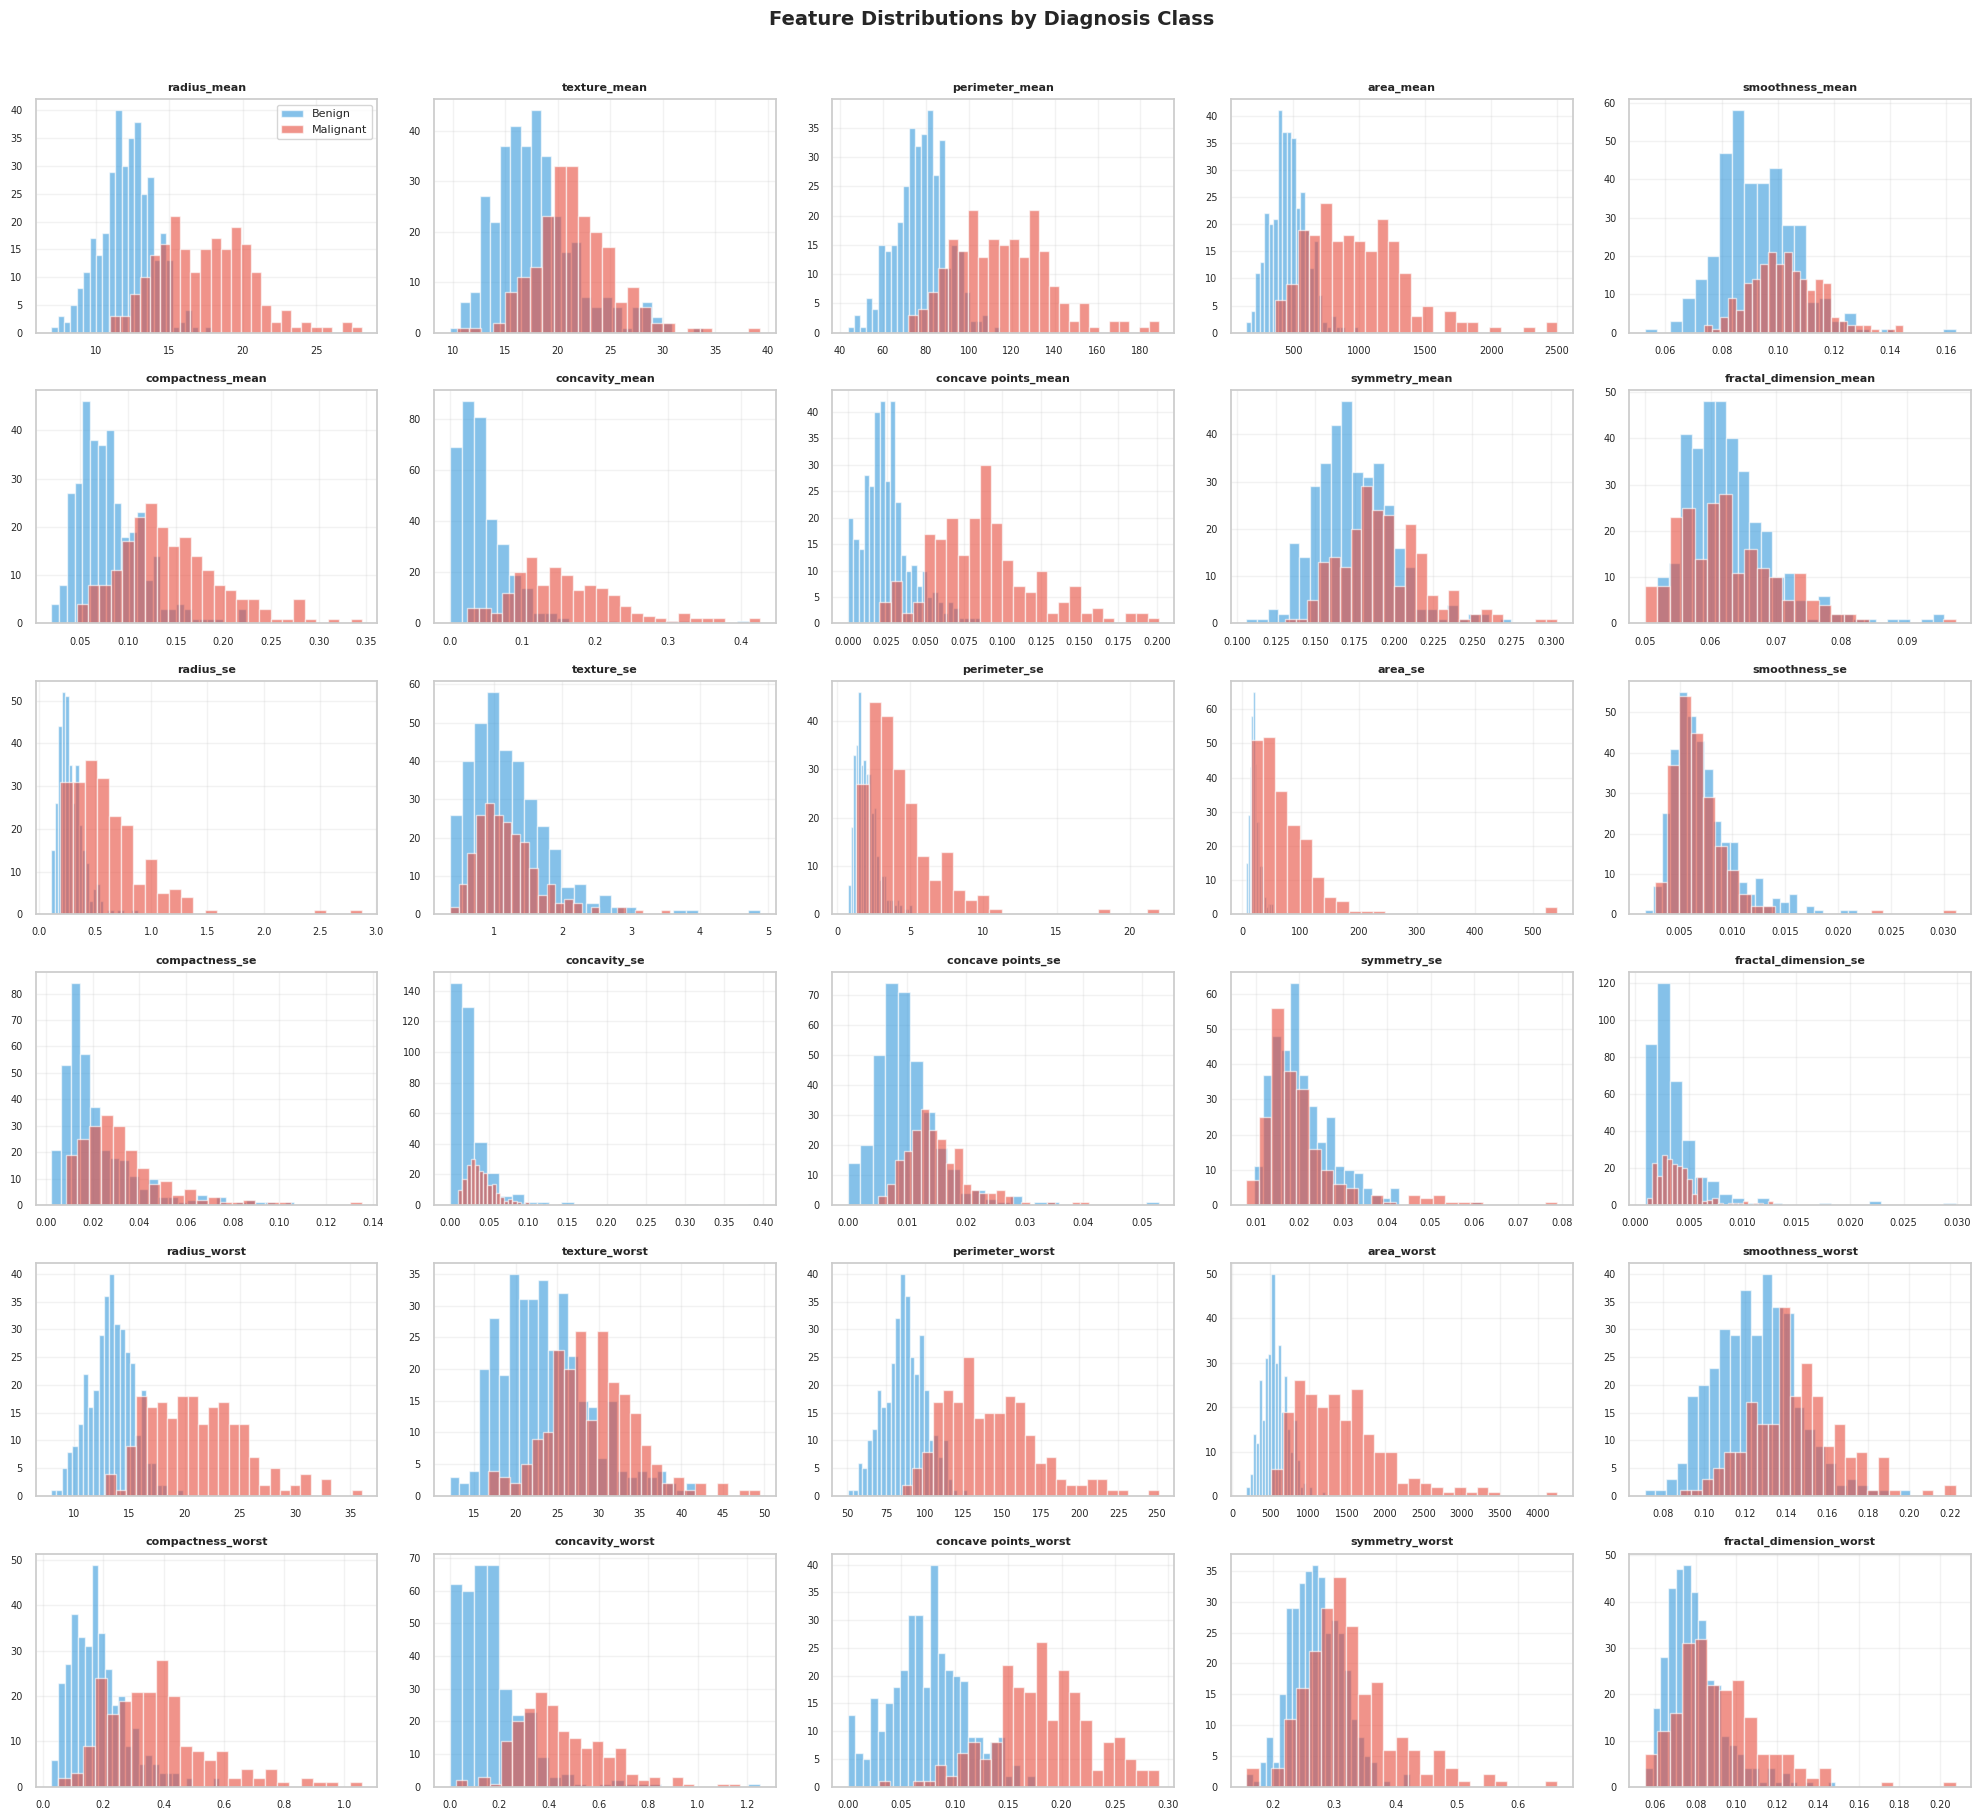

In [315]:
# Using one consistent plot type for all 30 features: overlaid histograms by diagnosis
fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.ravel()

for i, feat in enumerate(features):
    axes[i].hist(df.loc[df['diagnosis'] == 0, feat], bins=25, alpha=0.60,
                 label='Benign', color='#3498DB')
    axes[i].hist(df.loc[df['diagnosis'] == 1, feat], bins=25, alpha=0.60,
                 label='Malignant', color='#E74C3C')
    axes[i].set_title(feat, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    axes[i].grid(alpha=0.25)

axes[0].legend(fontsize=8)
plt.suptitle('Feature Distributions by Diagnosis Class', y=1.01,
             fontsize=14, fontweight='heavy')
plt.tight_layout()
plt.show()

**Interpretation:** The strongest visual separation appears in size- and shape-related features, especially several `_worst` measurements and selected `_mean` measurements. Features such as `concave points_worst`, `perimeter_worst`, `radius_worst`, `concave points_mean`, and `perimeter_mean` show clearly shifted malignant distributions, with malignant samples generally concentrated at higher values. For `concave points_mean`, the overlap between benign and malignant cases is limited but still visible in the middle range, so the feature is highly informative but not perfectly separating on its own.

In contrast, `fractal_dimension_mean`, `symmetry_mean`, and `texture_se` show much weaker standalone separation than the strongest morphology features. Their benign and malignant histograms overlap substantially, so these features do not provide a clean visual threshold between the two classes. `smoothness_mean` shows weak-to-moderate separation: malignant cases are slightly shifted toward higher values, but the two distributions still share much of their mass. `fractal_dimension_worst` shows a visible malignant right tail, including some larger malignant values, but it also has substantial overlap with benign cases in the lower-to-middle range. Overall, these patterns support training multivariate models rather than relying on any single feature for classification.

### 4.4 Feature-group comparison: `_mean`, `_se`, and `_worst`

The WDBC features are organized into three repeated summary types: `_mean`, `_se`, and `_worst`. Comparing these groups helps determine whether the predictive signal is concentrated in average measurements, variability measurements, or extreme measurements.


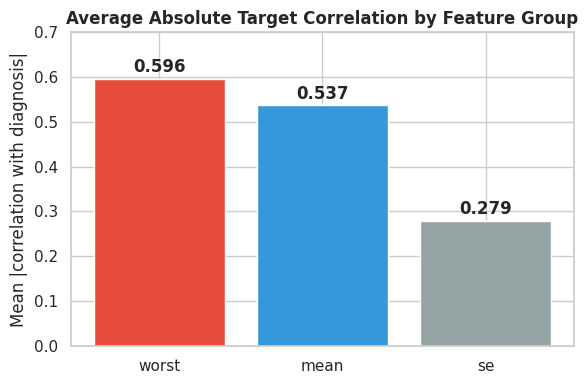

,0
worst,0.5956
mean,0.5368
se,0.2786


In [316]:
# Comparing feature groups by their average absolute correlation with the target
feature_groups = ['mean', 'se', 'worst']

target_corr_temp = df[features].corrwith(df['diagnosis'])
group_signal = {}
for group in feature_groups:
    group_cols = [c for c in features if c.endswith('_' + group)]
    group_signal[group] = target_corr_temp[group_cols].abs().mean()

group_signal = pd.Series(group_signal).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
group_colors = {'worst': '#E74C3C', 'mean': '#3498DB', 'se': '#95A5A6'}
bar_colors = [group_colors[g] for g in group_signal.index]
bars = ax.bar(group_signal.index, group_signal.values, color=bar_colors, edgecolor='white')
ax.set_title('Average Absolute Target Correlation by Feature Group',
             fontweight='bold')
ax.set_ylabel('Mean |correlation with diagnosis|')
ax.set_ylim(0, 0.70)

for bar, value in zip(bars, group_signal.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{value:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

group_signal.round(4)

**Interpretation:** The `_worst` group has the highest average absolute correlation with diagnosis (**0.5956**), followed by `_mean` (**0.5368**) and `_se` (**0.2786**). This is a useful dataset-specific pattern: the most extreme nuclear measurements are more discriminative than variability/error summaries. It also explains why many top features later come from the `_worst` group.


### 4.5 Correlation heatmap: checking multicollinearity

The heatmap checks relationships among the 30 predictors. This is not only descriptive; it affects modelling. Strongly correlated predictors can make Logistic Regression coefficients unstable and can split Random Forest importance across interchangeable variables.


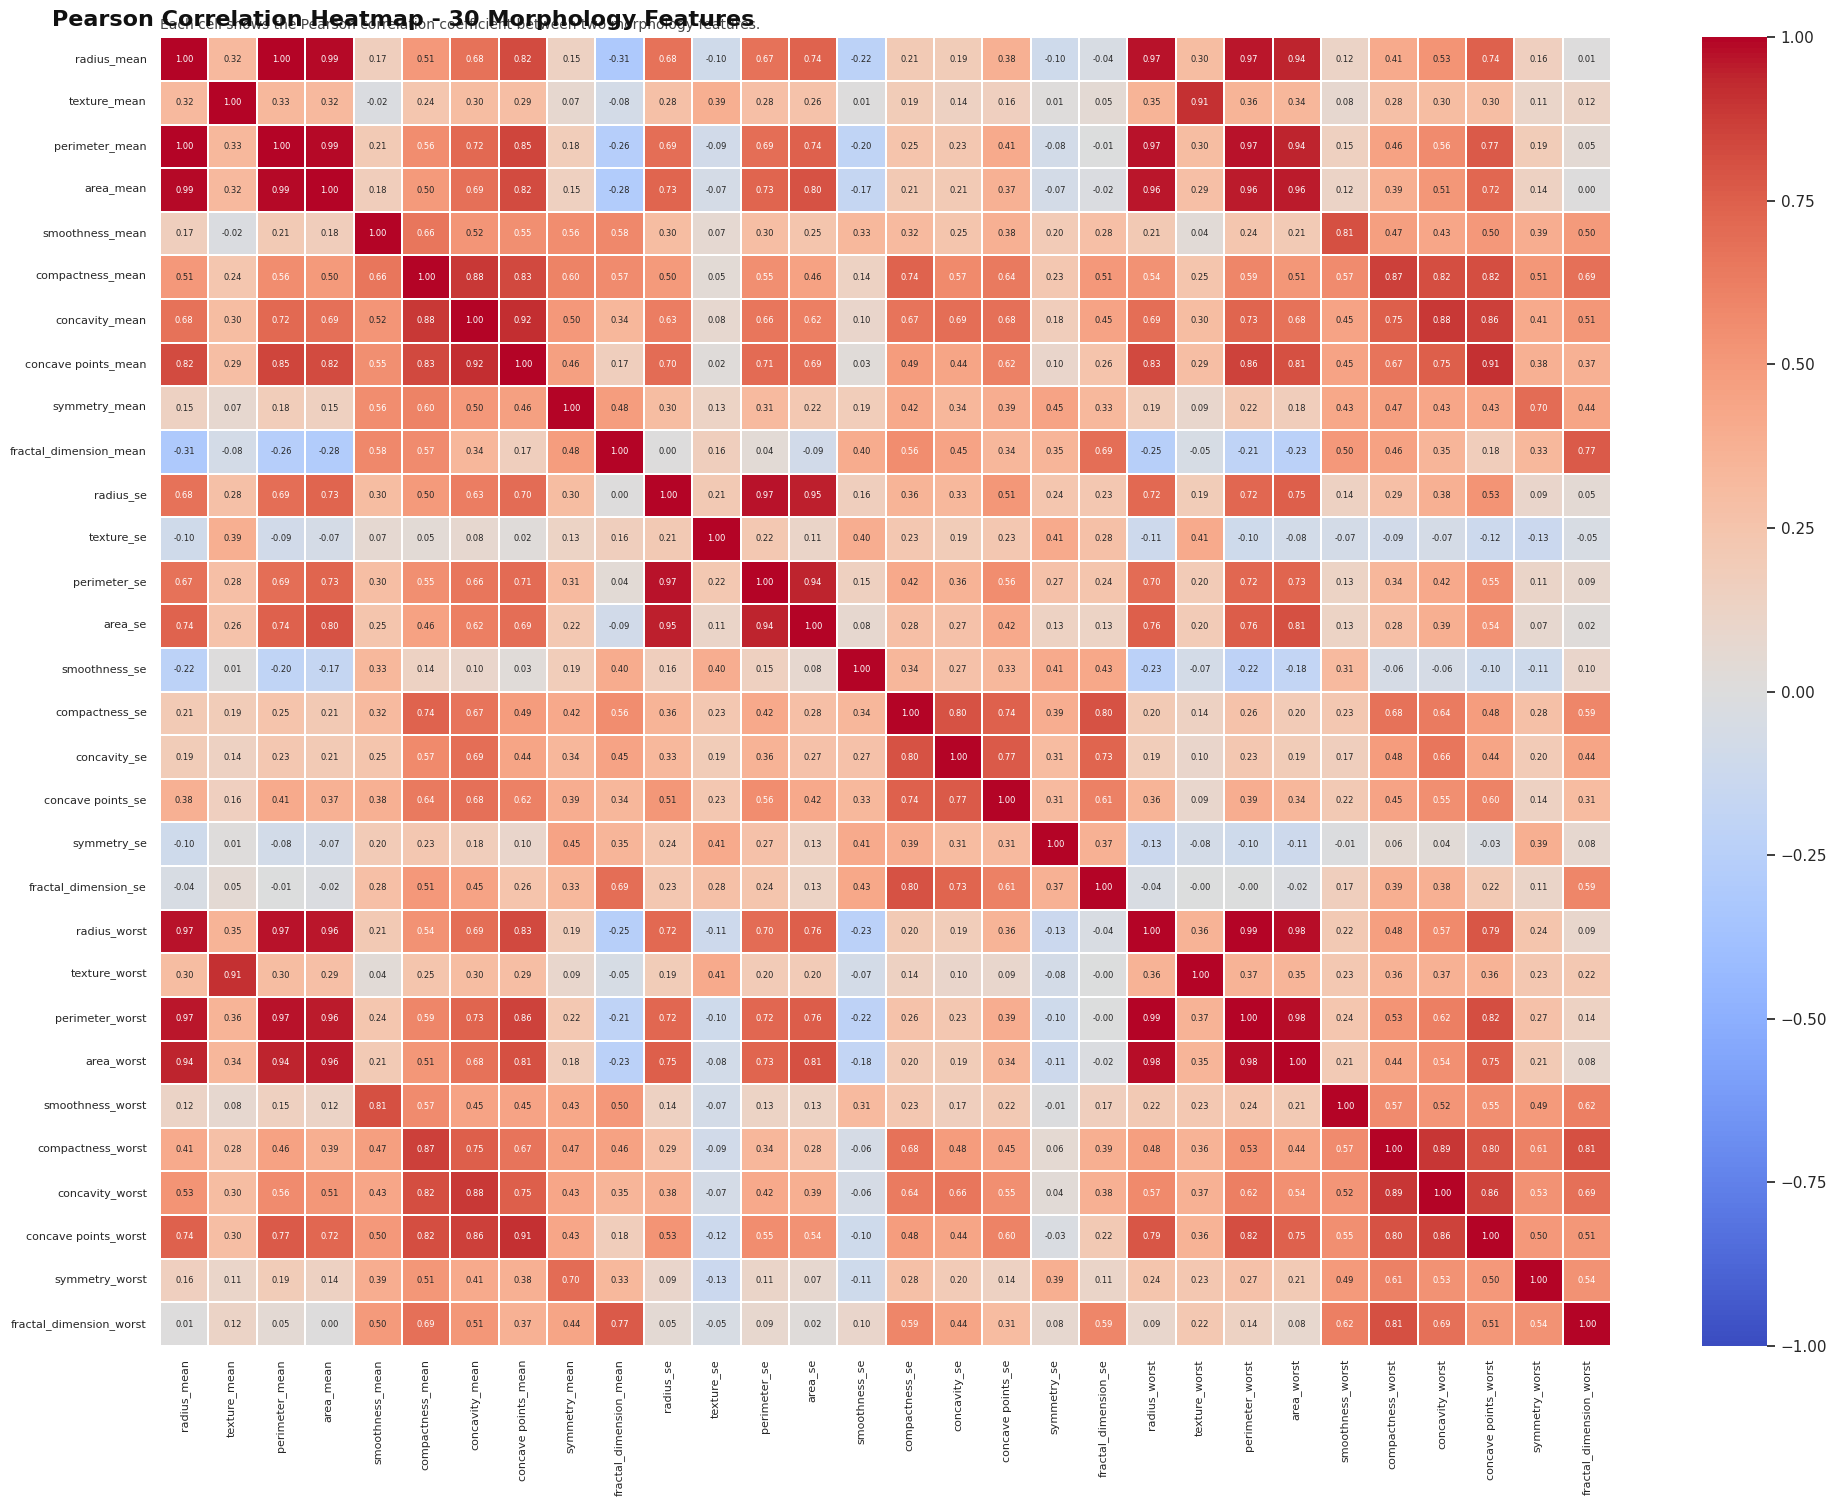

,feature_1,feature_2,correlation
1,radius_mean,perimeter_mean,0.9979
391,radius_worst,perimeter_worst,0.9937
2,radius_mean,area_mean,0.9874
57,perimeter_mean,area_mean,0.9865
392,radius_worst,area_worst,0.9840
407,perimeter_worst,area_worst,0.9776
246,radius_se,perimeter_se,0.9728
76,perimeter_mean,perimeter_worst,0.9704
19,radius_mean,radius_worst,0.9695
74,perimeter_mean,radius_worst,0.9695


In [317]:
# Correlation heatmap for all numeric predictors
feat_df = df.drop('diagnosis', axis=1)
corr_matrix = feat_df.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    linecolor='white',
    annot_kws={"size": 6}
)

plt.suptitle(
    'Pearson Correlation Heatmap - 30 Morphology Features',
    fontweight='heavy',
    x=0.03,
    y=0.98,
    ha='left',
    fontsize=16,
    fontfamily='sans-serif',
    color='#111111'
)

plt.title(
    'Each cell shows the Pearson correlation coefficient between two morphology features.',
    fontsize=10,
    fontfamily='sans-serif',
    loc='left',
    color='#444444'
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout(rect=[0, 0.04, 1, 1.01])
plt.show()

# Identify the strongest off-diagonal correlations for precise interpretation
corr_abs = corr_matrix.abs()
np.fill_diagonal(corr_abs.values, 0)

top_corr_pairs = []
for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        top_corr_pairs.append({
            'feature_1': corr_abs.columns[i],
            'feature_2': corr_abs.columns[j],
            'correlation': corr_matrix.iloc[i, j],
            'abs_correlation': abs(corr_matrix.iloc[i, j])
        })

top_corr_pairs = (
    pd.DataFrame(top_corr_pairs)
    .sort_values('abs_correlation', ascending=False)
    .head(10)
)

top_corr_pairs[['feature_1', 'feature_2', 'correlation']].round(4)

The annotated heatmap confirms strong multicollinearity among several size-related features, especially radius, perimeter, area, and their worst-value versions. This supports the need to compare regularized models and to include feature selection as a diagnostic step.

**Heatmap interpretation:** The strongest off-diagonal relationship is between `radius_mean` and `perimeter_mean` (**ρ = 0.9979**). Other near-duplicate relationships also appear between radius, perimeter, and area measurements. This is expected because these features are mathematically and geometrically related. The implication is important: individual feature rankings should be interpreted by **feature family**, not as exact causal rankings of isolated variables.


### 4.6 Feature-target correlations

Point-biserial correlation is equivalent to Pearson correlation when one variable is binary. Here it measures how strongly each numeric feature is linearly associated with the encoded diagnosis label (`M = 1`, `B = 0`).


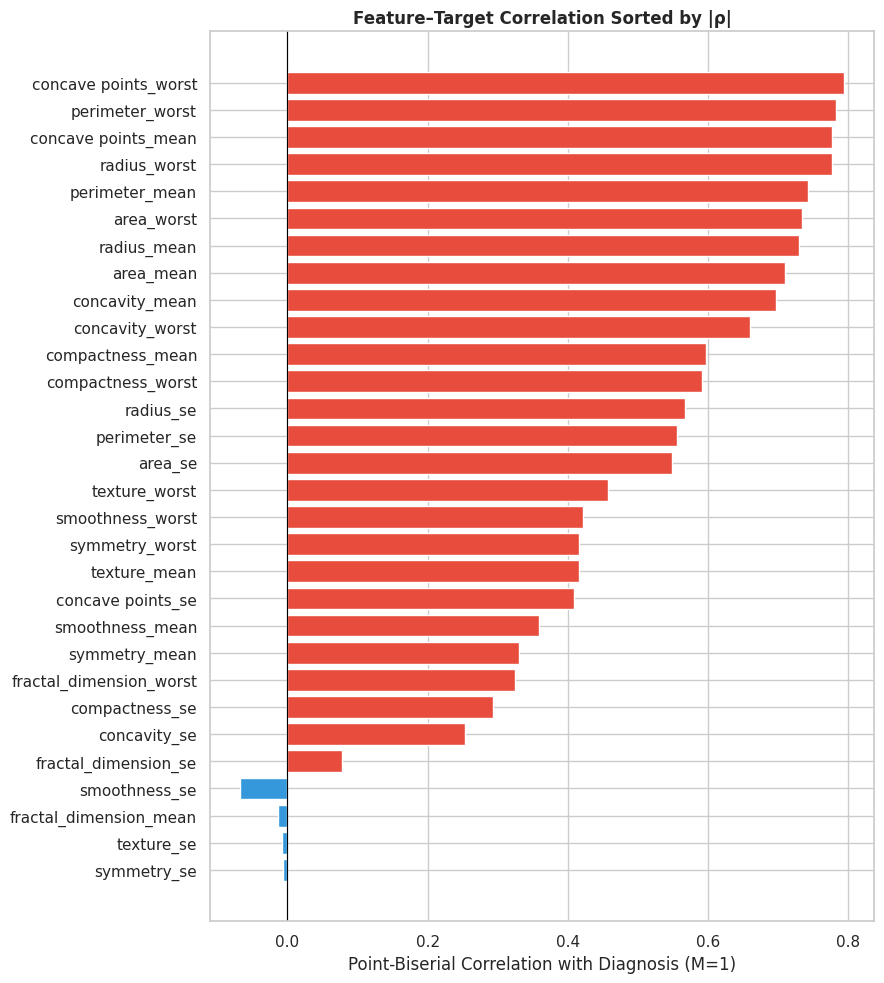

Top 10 features by absolute correlation with diagnosis:


,0
concave points_worst,0.7936
perimeter_worst,0.7829
concave points_mean,0.7766
radius_worst,0.7765
perimeter_mean,0.7426
area_worst,0.7338
radius_mean,0.7300
area_mean,0.7090
concavity_mean,0.6964
concavity_worst,0.6596


In [318]:
# Compute and visualize feature-target correlations
target_corr = feat_df.corrwith(df['diagnosis']).sort_values(key=abs, ascending=False)

colors = ['#E74C3C' if v > 0 else '#3498DB' for v in target_corr]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(target_corr.index[::-1], target_corr.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with Diagnosis (M=1)')
ax.set_title('Feature–Target Correlation Sorted by |ρ|',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features by absolute correlation with diagnosis:')
target_corr.head(10).round(4)

**Top target-correlated features:** The five strongest correlations are `concave points_worst` (**0.7936**), `perimeter_worst` (**0.7829**), `concave points_mean` (**0.7766**), `radius_worst` (**0.7765**), and `perimeter_mean` (**0.7426**). These are all size/shape measurements. The conclusion should therefore be specific: in this dataset, malignancy is most strongly associated with larger and more irregular nuclei, especially concave-point and perimeter-related measurements.

`concavity_mean` is also relevant, but it is not among the five strongest features by this specific univariate correlation ranking. This distinction matters because feature importance depends on the criterion being used.


### 4.7 Focused EDA of the strongest features

The broad grid is useful for overview, but the most important features need closer inspection. For each top feature, I use the same two-plot structure:

1. a boxplot by diagnosis to compare medians, IQRs, and outliers,
2. an overlaid histogram to inspect class overlap and distribution shape.

This is intentionally consistent across features so that the comparisons are methodologically coherent.


In [319]:
def plot_feature_by_diagnosis(var, display_name, color='#3498DB'):
    """Create a two-panel EDA plot for one numeric feature by diagnosis class."""
    title_color = '#111111'
    label_color = '#444444'

    print(f'--- {display_name}: Overall distribution shape ---')
    print(f'  Overall skewness : {df[var].skew(axis=0, skipna=True):.3f}')
    print(f'  Overall kurtosis : {df[var].kurt(axis=0, skipna=True):.3f}')
    print()

    print('Distribution shape by diagnosis:')
    shape_by_class = (
        df.groupby('diagnosis')[var]
          .agg(
              count='count',
              skewness=lambda x: x.skew(),
              kurtosis=lambda x: x.kurt()
          )
          .rename(index={0: 'Benign (0)', 1: 'Malignant (1)'})
          .round(4)
    )
    display(shape_by_class)

    print('Quartiles by diagnosis:')
    display(
        df.groupby('diagnosis')[var]
          .describe()[['25%', '50%', '75%', 'min', 'max']]
          .rename(index={0: 'Benign (0)', 1: 'Malignant (1)'})
          .round(4)
    )

    plot_df = df[[var, 'diagnosis']].copy()
    plot_df['Diagnosis'] = plot_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})

    fig = plt.figure(figsize=(13, 5))
    fig.suptitle(f'{display_name} by Diagnosis', fontweight='bold',
                 fontsize=16, fontfamily='sans-serif', color=title_color)
    fig.subplots_adjust(top=0.82)

    # Boxplot
    ax1 = fig.add_subplot(1, 2, 1)
    sns.boxplot(data=plot_df, x='Diagnosis', y=var, ax=ax1,
                palette=['#3498DB', '#E74C3C'])
    ax1.set_title('Box Plot by Class', fontweight='bold', fontsize=13,
                  fontfamily='sans-serif', color=title_color)
    ax1.set_xlabel('')
    ax1.set_ylabel(display_name, fontweight='regular', fontsize=11,
                   fontfamily='sans-serif', color=label_color)

    # Histogram
    ax2 = fig.add_subplot(1, 2, 2)
    sns.histplot(data=plot_df, x=var, hue='Diagnosis', bins=25, kde=True,
                 element='step', stat='count', common_norm=False,
                 palette=['#3498DB', '#E74C3C'], ax=ax2)
    ax2.set_title('Histogram by Class', fontweight='bold', fontsize=13,
                  fontfamily='sans-serif', color=title_color)
    ax2.set_xlabel(display_name, fontweight='regular', fontsize=11,
                   fontfamily='sans-serif', color=label_color)
    ax2.set_ylabel('Count', fontweight='regular', fontsize=11,
                   fontfamily='sans-serif', color=label_color)

    plt.tight_layout()
    plt.show()

#### 4.7.1 `concave points_worst`

This is the strongest single feature by absolute target correlation. It measures the largest/worst observed value of concave points among the nuclei in a sample.


--- Worst Concave Points: Overall distribution shape ---
  Overall skewness : 0.493
  Overall kurtosis : -0.536

Distribution shape by diagnosis:


,count,skewness,kurtosis
diagnosis,,,
Benign (0),357,0.1123,-0.1645
Malignant (1),212,-0.0928,0.1359


Quartiles by diagnosis:


,25%,50%,75%,min,max
diagnosis,,,,,
Benign (0),0.0510,0.0743,0.0975,0.000,0.175
Malignant (1),0.1528,0.1820,0.2107,0.029,0.291


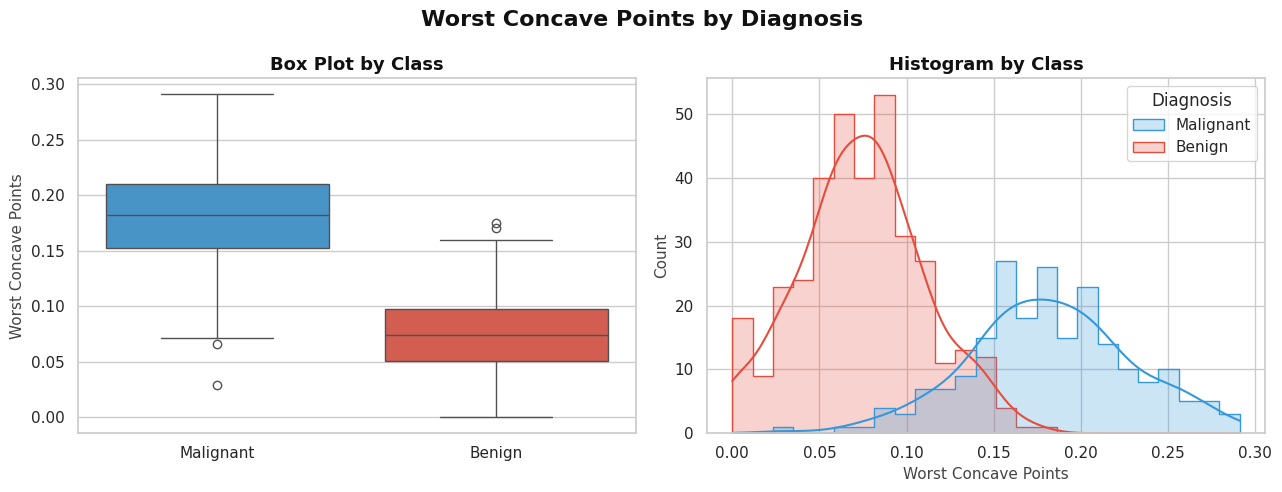

,count,skewness,kurtosis,q1,median,q3,minimum,maximum
diagnosis_label,,,,,,,,
Benign (0),357,0.1123,-0.1645,0.0510,0.0743,0.0975,0.000,0.175
Malignant (1),212,-0.0928,0.1359,0.1528,0.1820,0.2107,0.029,0.291


In [320]:
plot_feature_by_diagnosis('concave points_worst', 'Worst Concave Points')

# Summary statistics for concave_points_worst by diagnosis
feature = 'concave points_worst'

shape_summary = (
    df.assign(diagnosis_label=df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'}))
      .groupby('diagnosis_label')[feature]
      .agg(
          count='count',
          skewness=lambda x: x.skew(),
          kurtosis=lambda x: x.kurtosis(),
          q1=lambda x: x.quantile(0.25),
          median='median',
          q3=lambda x: x.quantile(0.75),
          minimum='min',
          maximum='max'
      )
      .round(4)
)

shape_summary

**Distribution analysis:** `concave points_worst` shows the cleanest univariate separation. The benign IQR is **0.0510–0.0975**, while the malignant IQR is **0.1528–0.2107**. The central 50% of the two classes do not overlap. This supports the correlation result and explains why this feature is repeatedly important in later model interpretation.

**Distribution shape:** The class-specific skewness values show a more precise pattern than simply calling both classes right-skewed. The benign class is only mildly right-skewed (skewness ≈ **0.11**), while the malignant class is close to symmetric/slightly left-skewed (skewness ≈ **-0.09**). The benign histogram concentrates near lower values, with a small number of benign samples extending toward the malignant range. The malignant distribution is more spread, with many values roughly between 0.10 and 0.25. The separation between classes is strong, but the overlap region remains the area where misclassifications are most plausible.


#### 4.7.2 `perimeter_worst`

`perimeter_worst` is the second strongest feature by absolute target correlation. It captures the largest/worst perimeter measurement and is strongly related to tumor size.


--- Worst Perimeter: Overall distribution shape ---
  Overall skewness : 1.128
  Overall kurtosis : 1.070

Distribution shape by diagnosis:


,count,skewness,kurtosis
diagnosis,,,
Benign (0),357,0.0087,-0.2302
Malignant (1),212,0.7482,0.6154


Quartiles by diagnosis:


,25%,50%,75%,min,max
diagnosis,,,,,
Benign (0),78.270,86.92,96.59,50.41,127.1
Malignant (1),119.325,138.00,159.80,85.10,251.2


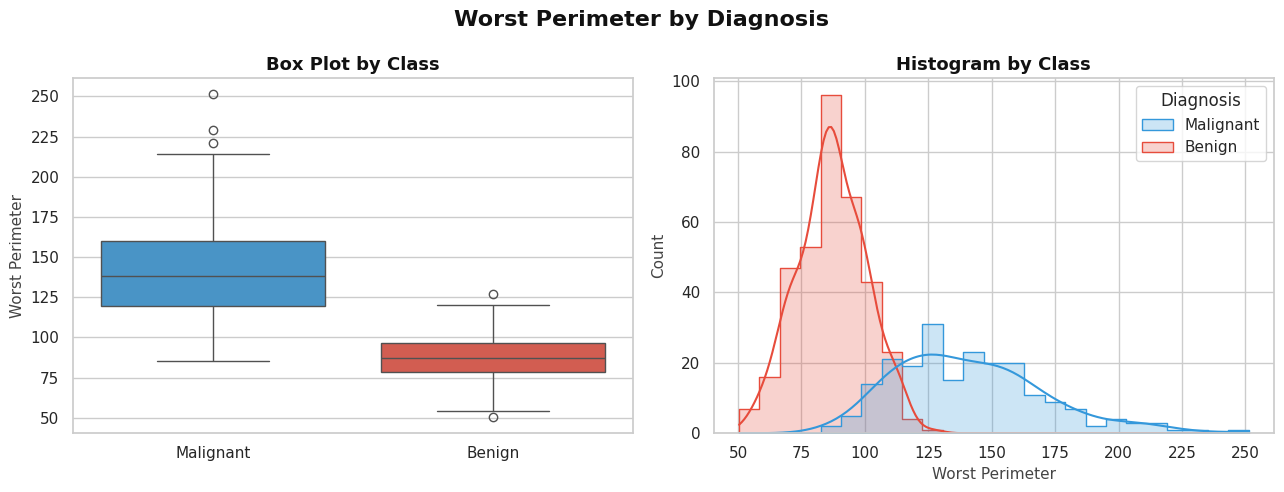

,count,skewness,kurtosis,q1,median,q3,minimum,maximum
diagnosis_label,,,,,,,,
Benign (0),357,0.0087,-0.2302,78.270,86.92,96.59,50.41,127.1
Malignant (1),212,0.7482,0.6154,119.325,138.00,159.80,85.10,251.2


In [321]:
plot_feature_by_diagnosis('perimeter_worst', 'Worst Perimeter')

# Summary statistics for perimeter_worst by diagnosis
feature = 'perimeter_worst'

perimeter_worst_summary = (
    df.assign(diagnosis_label=df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'}))
      .groupby('diagnosis_label')[feature]
      .agg(
          count='count',
          skewness=lambda x: x.skew(),
          kurtosis=lambda x: x.kurtosis(),
          q1=lambda x: x.quantile(0.25),
          median='median',
          q3=lambda x: x.quantile(0.75),
          minimum='min',
          maximum='max'
      )
      .round(4)
)

perimeter_worst_summary

**Distribution analysis:** `perimeter_worst` shows strong univariate class separation. The benign median is **86.92**, while the malignant median is **138.00**. The malignant lower quartile (**119.33**) is above the benign upper quartile (**96.59**), so the central 50% of the two classes do not overlap. The remaining overlap comes from smaller malignant cases and larger benign cases, which are likely candidates for harder classification decisions.

**Distribution shape:** The class-specific skewness values show that the benign distribution is nearly symmetric (skewness ≈ **0.01**), while the malignant distribution is clearly right-skewed (skewness ≈ **0.75**). The malignant distribution has a visible right tail: only a minority of malignant samples have `perimeter_worst` values above **200**, but these large values extend the distribution toward the high end, visible in the upper tail of the histogram and the high-end points of the boxplot. The benign distribution is tighter and has fewer extreme high values, which is consistent with benign cases having smaller worst-perimeter measurements on this feature.

#### 4.7.3 `concave points_mean`

`concave points_mean` is the third strongest target-correlated feature. It measures the average concave-point value rather than the worst-case value.


--- Mean Concave Points: Overall distribution shape ---
  Overall skewness : 1.171
  Overall kurtosis : 1.067

Distribution shape by diagnosis:


,count,skewness,kurtosis
diagnosis,,,
Benign (0),357,0.9250,1.0380
Malignant (1),212,0.7391,0.7301


Quartiles by diagnosis:


,25%,50%,75%,min,max
diagnosis,,,,,
Benign (0),0.0150,0.0234,0.0325,0.0000,0.0853
Malignant (1),0.0646,0.0863,0.1032,0.0203,0.2012


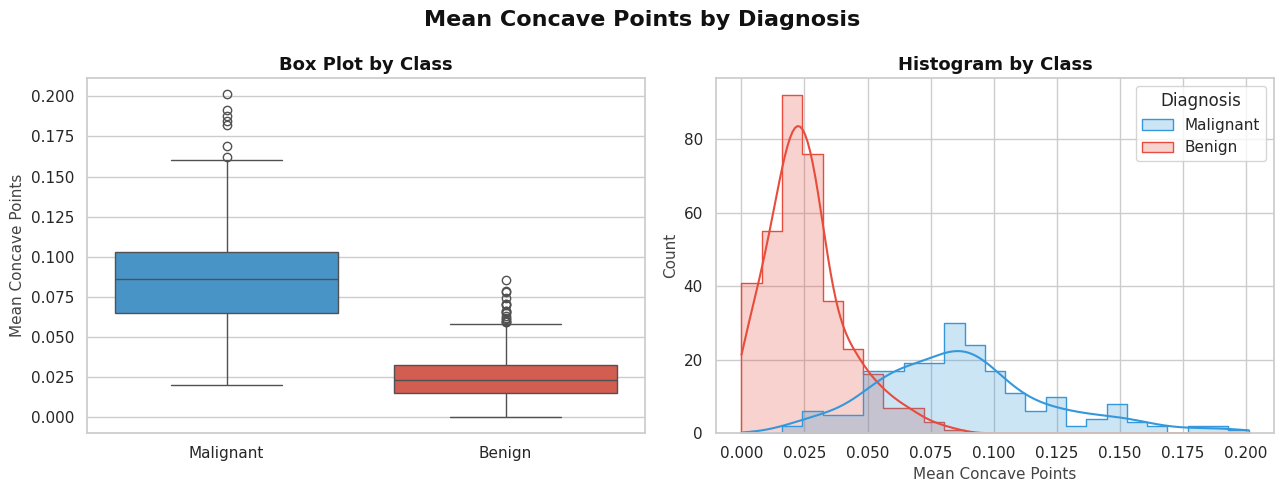

,count,skewness,kurtosis,q1,median,q3,minimum,maximum
diagnosis_label,,,,,,,,
Benign (0),357,0.9250,1.0380,0.0150,0.0234,0.0325,0.0000,0.0853
Malignant (1),212,0.7391,0.7301,0.0646,0.0863,0.1032,0.0203,0.2012


In [322]:
plot_feature_by_diagnosis('concave points_mean', 'Mean Concave Points')

# Summary statistics for concave_points_mean by diagnosis
feature = 'concave points_mean'

concave_points_mean_summary = (
    df.assign(diagnosis_label=df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'}))
      .groupby('diagnosis_label')[feature]
      .agg(
          count='count',
          skewness=lambda x: x.skew(),
          kurtosis=lambda x: x.kurtosis(),
          q1=lambda x: x.quantile(0.25),
          median='median',
          q3=lambda x: x.quantile(0.75),
          minimum='min',
          maximum='max'
      )
      .round(4)
)

concave_points_mean_summary

**Distribution analysis:** `concave points_mean` shows strong univariate class separation. The benign IQR is **0.0150–0.0325**, while the malignant IQR is **0.0646–0.1032**, so the central 50% of the two classes do not overlap. This supports the correlation result and shows that concave-point morphology is informative not only in the `_worst` measurement, but also in the average measurement.

**Distribution shape:** The class-specific skewness values support a right-skew interpretation for both classes: benign skewness ≈ **0.92** and malignant skewness ≈ **0.74**. The benign distribution is concentrated at lower values, with a right tail extending toward larger `concave points_mean` values. The malignant distribution is broader and shifted toward higher values, while also remaining positively skewed because some malignant samples have especially high mean concave-point values. This feature therefore provides strong class-separation information, although the histogram still shows some overlap in the middle range.

#### 4.7.4 `radius_worst`

`radius_worst` ranks fourth by absolute target correlation. Since radius, perimeter, and area are highly correlated, this feature should be interpreted as part of a broader size-related feature family.


--- Worst Radius: Overall distribution shape ---
  Overall skewness : 1.103
  Overall kurtosis : 0.944

Distribution shape by diagnosis:


,count,skewness,kurtosis
diagnosis,,,
Benign (0),357,-0.0316,-0.1631
Malignant (1),212,0.6315,0.3245


Quartiles by diagnosis:


,25%,50%,75%,min,max
diagnosis,,,,,
Benign (0),12.08,13.35,14.8000,7.93,19.82
Malignant (1),17.73,20.59,23.8075,12.84,36.04


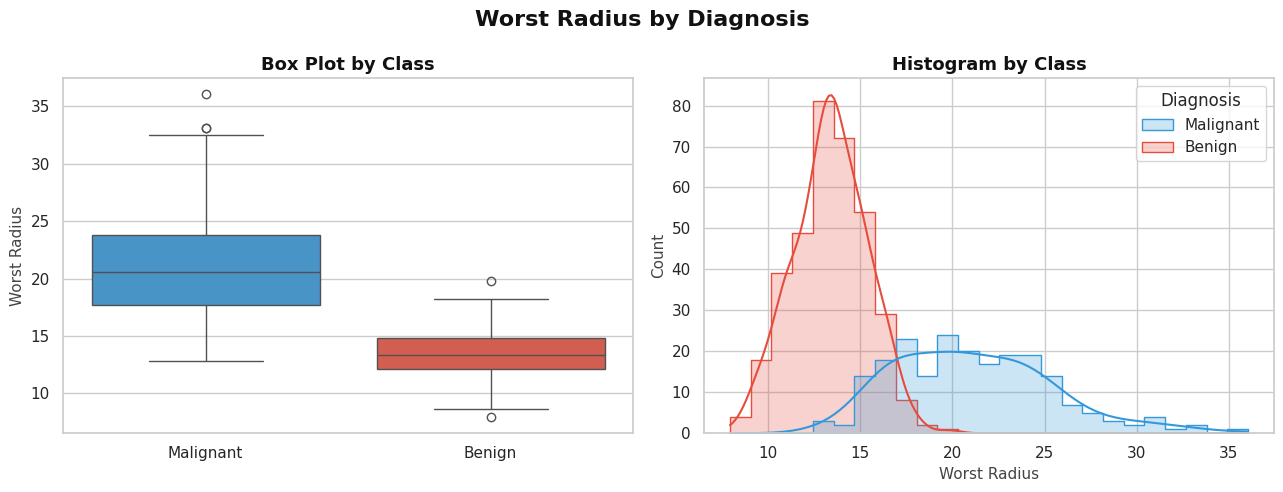

,count,skewness,kurtosis,q1,median,q3,minimum,maximum
diagnosis_label,,,,,,,,
Benign (0),357,-0.0316,-0.1631,12.08,13.35,14.8000,7.93,19.82
Malignant (1),212,0.6315,0.3245,17.73,20.59,23.8075,12.84,36.04


In [323]:
plot_feature_by_diagnosis('radius_worst', 'Worst Radius')

# Summary statistics for radius_worst by diagnosis
feature = 'radius_worst'

radius_worst_summary = (
    df.assign(diagnosis_label=df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'}))
      .groupby('diagnosis_label')[feature]
      .agg(
          count='count',
          skewness=lambda x: x.skew(),
          kurtosis=lambda x: x.kurtosis(),
          q1=lambda x: x.quantile(0.25),
          median='median',
          q3=lambda x: x.quantile(0.75),
          minimum='min',
          maximum='max'
      )
      .round(4)
)

radius_worst_summary

**Distribution analysis:** `radius_worst` shows strong univariate class separation. The benign median is **13.35**, while the malignant median is **20.59**. The malignant IQR (**17.73–23.81**) lies well above the benign IQR (**12.08–14.80**), so the central 50% of the two classes do not overlap. This supports the conclusion that malignant cases tend to have larger worst-radius measurements. Because radius, perimeter, and area are strongly correlated size-related features, this result should be interpreted as part of a broader size-measurement pattern rather than as an independent signal.

**Distribution shape:** The class-specific skewness values show that the benign distribution is approximately symmetric, with negligible negative skewness (skewness ≈ **-0.03**), while the malignant distribution is moderately right-skewed (skewness ≈ **0.63**). The malignant distribution is also more spread out, with some malignant samples extending toward much larger `radius_worst` values. Compared with `concave points_worst`, the class separation is slightly less clean because some larger benign cases and smaller malignant cases overlap in the middle range. Therefore, `radius_worst` is highly informative, but it should be interpreted together with the other size-related features rather than as a fully independent separator.

#### 4.7.5 `perimeter_mean`

`perimeter_mean` is the strongest `_mean` feature among the size-related measurements (`radius_mean`, `perimeter_mean`, and `area_mean`) by absolute target correlation, and it is the only `_mean` size-related feature in the overall top five. It helps check whether the class separation exists only in worst-case measurements or also in average morphology.


--- Mean Perimeter: Overall distribution shape ---
  Overall skewness : 0.991
  Overall kurtosis : 0.972

Distribution shape by diagnosis:


,count,skewness,kurtosis
diagnosis,,,
Benign (0),357,-0.0647,-0.0165
Malignant (1),212,0.6049,0.5912


Quartiles by diagnosis:


,25%,50%,75%,min,max
diagnosis,,,,,
Benign (0),70.870,78.18,86.100,43.79,114.6
Malignant (1),98.745,114.20,129.925,71.90,188.5


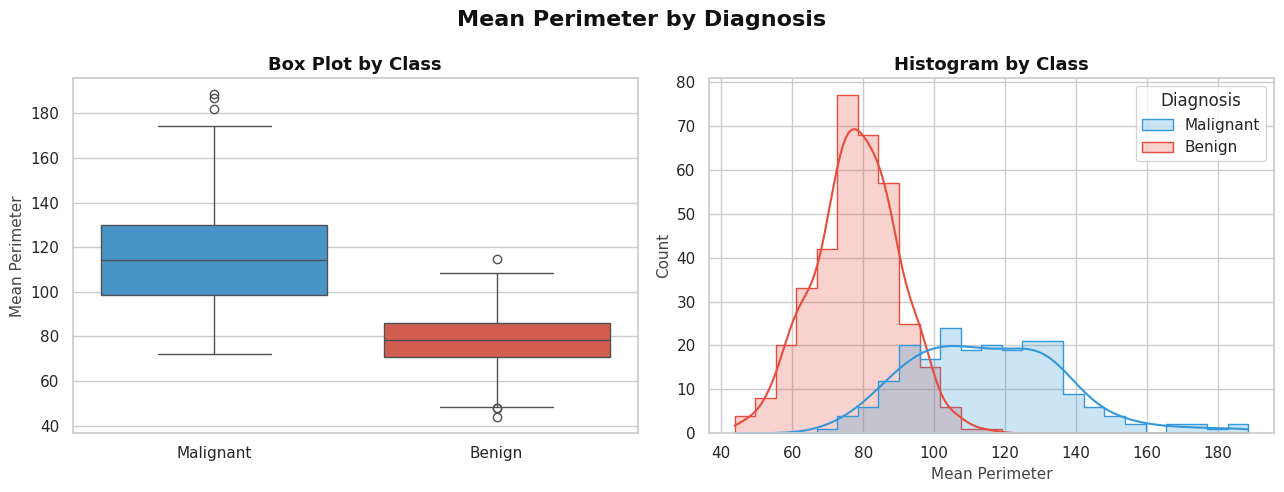

,count,skewness,kurtosis,q1,median,q3,minimum,maximum
diagnosis_label,,,,,,,,
Benign (0),357,-0.0647,-0.0165,70.870,78.18,86.100,43.79,114.6
Malignant (1),212,0.6049,0.5912,98.745,114.20,129.925,71.90,188.5


In [324]:
plot_feature_by_diagnosis('perimeter_mean', 'Mean Perimeter')

# Summary statistics for perimeter_mean by diagnosis
feature = 'perimeter_mean'

perimeter_mean_summary = (
    df.assign(diagnosis_label=df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'}))
      .groupby('diagnosis_label')[feature]
      .agg(
          count='count',
          skewness=lambda x: x.skew(),
          kurtosis=lambda x: x.kurtosis(),
          q1=lambda x: x.quantile(0.25),
          median='median',
          q3=lambda x: x.quantile(0.75),
          minimum='min',
          maximum='max'
      )
      .round(4)
)

perimeter_mean_summary

**Distribution analysis:** `perimeter_mean` shows strong univariate class separation. The benign median is **78.18**, while the malignant median is **114.20**. The malignant IQR (**98.75–129.93**) lies above the benign IQR (**70.87–86.10**), so the central 50% of the two classes do not overlap. This shows that the class separation is not limited to `_worst` features; the average perimeter measurement also carries strong class-separation information.

**Distribution shape:** The class-specific skewness values show that the benign distribution is approximately symmetric, with negligible negative skewness (skewness ≈ **-0.06**), while the malignant distribution is moderately right-skewed (skewness ≈ **0.60**). The malignant distribution is broader and shifted toward higher `perimeter_mean` values, with some malignant samples extending into the high-value range. Compared with `perimeter_worst`, the class overlap is slightly larger here, which is consistent with mean measurements being less extreme than worst-case measurements.

### 4.8 Two-feature relationship: strongest shape and size signals

A scatter plot can show whether two strong features separate the classes jointly. I use `concave points_worst` and `perimeter_worst` because they are the two highest-ranked features by absolute target correlation.


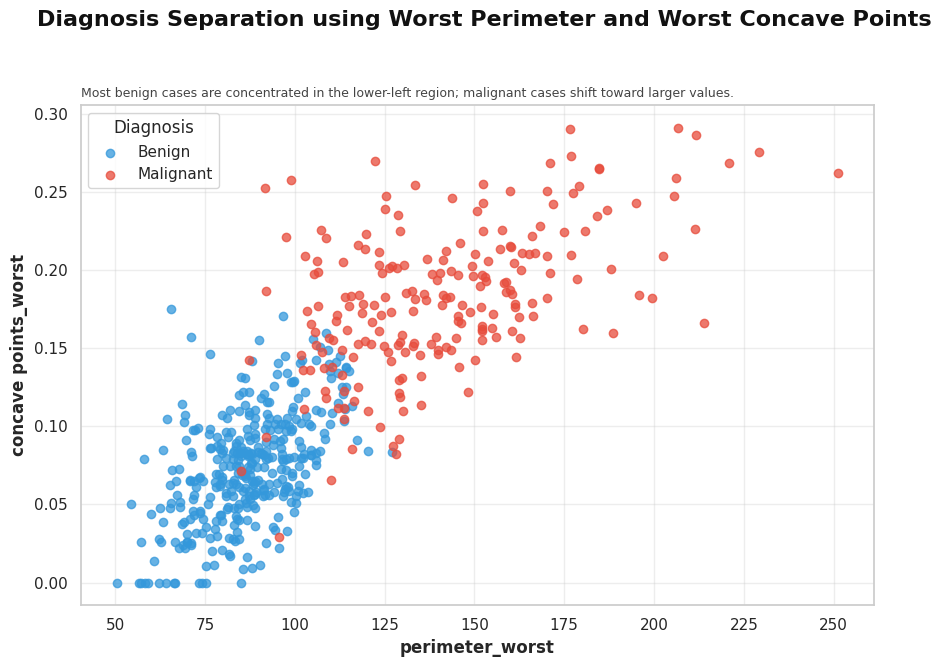

In [325]:
# This scatter plot checks whether the two strongest univariate features also separate the classes jointly
plt.figure(figsize=(9, 7))

plt.suptitle('Diagnosis Separation using Worst Perimeter and Worst Concave Points',
             fontweight='heavy', x=0.05, y=0.98, ha='left',
             fontsize=16, fontfamily='sans-serif', color='#111111')
plt.title('Most benign cases are concentrated in the lower-left region; malignant cases shift toward larger values.',
          fontsize=9, fontfamily='sans-serif', loc='left', color='#444444')

plt.scatter(
    df.loc[df['diagnosis'] == 0, 'perimeter_worst'],
    df.loc[df['diagnosis'] == 0, 'concave points_worst'],
    c='#3498DB', alpha=0.75, label='Benign'
)
plt.scatter(
    df.loc[df['diagnosis'] == 1, 'perimeter_worst'],
    df.loc[df['diagnosis'] == 1, 'concave points_worst'],
    c='#E74C3C', alpha=0.75, label='Malignant'
)

plt.xlabel('perimeter_worst', fontweight='bold')
plt.ylabel('concave points_worst', fontweight='bold')
plt.grid(alpha=0.35)
plt.legend(title='Diagnosis')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Interpretation:** The two features jointly create a visible separation pattern: benign cases cluster toward lower `perimeter_worst` and lower `concave points_worst`, while malignant cases are shifted upward and to the right. However, the classes are not perfectly separable; there is overlap in the middle region. This justifies training supervised classifiers rather than assuming a simple manual threshold is sufficient.


## 5. Preprocessing and Data Splitting

### 5.1 Define Predictors and Target Variable
The predictor matrix `X` contains the 30 numeric morphology features, while the target vector `y` contains the encoded diagnosis label (`0 = benign`, `1 = malignant`).

In [326]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
print(f'Feature matrix X: {X.shape}  |  Target vector y: {y.shape}')
print(f'Feature dtypes - all numeric: {X.dtypes.unique()}')

Feature matrix X: (569, 30)  |  Target vector y: (569,)
Feature dtypes - all numeric: [dtype('float64')]


### 5.2 - Train/Test Split

We reserve 20% of samples as a held-out test set. **Stratified splitting** (`stratify=y`) is essential here: the 357/212 class imbalance means that a purely random split could, by chance, place a disproportionate share of the 212 malignant cases in either the train or test fold. Stratification preserves the 62.7% benign / 37.3% malignant distribution in both subsets, making the internal test set a fairer hold-out evaluation split.

This split is still **internal validation only**. It estimates performance on unseen samples from the same dataset, but it does not prove generalisation to independent hospitals, scanners, populations, or future clinical cohorts.

In [327]:
# stratify=y preserves the 63/37 class ratio in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])
print()
print('Train class proportions:')
print(y_train.value_counts(normalize=True).round(4))
print()
print('Test class proportions:')
print(y_test.value_counts(normalize=True).round(4))

Train size: 455 | Test size: 114

Train class proportions:
diagnosis
0    0.6264
1    0.3736
Name: proportion, dtype: float64

Test class proportions:
diagnosis
0    0.6316
1    0.3684
Name: proportion, dtype: float64


**Interpretation:** Both train and test proportions are approximately 62.7% benign / 37.3% malignant, matching the full dataset to within rounding. Stratification has worked correctly. The test set is therefore representative of the class balance in this dataset, although it is still only an internal hold-out split from the same cohort.


### 5.3 Training-Only Feature Selection Diagnostic

Because the correlation heatmap showed strong redundancy among size-related features, I include a feature-selection diagnostic. `SelectKBest(f_classif, k=10)` is fitted **only on the training set** to avoid test-set leakage. I then compare a `LogReg_KBest10` pipeline against the full-feature models in cross-validation; the final model uses feature selection only if it improves validation performance.


In [328]:
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

feature_selection_table = (
    pd.DataFrame({
        'feature': X.columns,
        'anova_f_score': selector.scores_,
        'selected_top10': selector.get_support()
    })
    .sort_values('anova_f_score', ascending=False)
)

selected_features = feature_selection_table.loc[feature_selection_table['selected_top10'], 'feature'].tolist()
print('Top 10 features selected on training data only:')
print(feature_selection_table.head(10).round(4).to_string(index=False))

Top 10 features selected on training data only:
             feature  anova_f_score  selected_top10
concave points_worst       733.7249            True
     perimeter_worst       717.2465            True
        radius_worst       692.8614            True
 concave points_mean       684.5268            True
      perimeter_mean       548.4132            True
          area_worst       522.1889            True
         radius_mean       511.2748            True
           area_mean       444.8575            True
      concavity_mean       397.5921            True
     concavity_worst       319.5078            True


**Interpretation:** The selected features are almost entirely the same size/shape variables highlighted by EDA: concave points, perimeter, radius, area, and concavity. This is useful evidence, but it does **not** automatically justify removing the other 20 features. The next section tests a selected-feature Logistic Regression pipeline inside cross-validation; if it performs worse than the full-feature model, the correct decision is to keep all features despite redundancy.


### 5.4 Preprocessing Decision Summary

| Decision | Justification |
|---|---|
| **No imputation** | Section 2 confirmed zero missing values. Imputation is therefore excluded because it is not justified by the actual dataset. |
| **Drop `id`** | `id` is an identifier, not a morphology measurement. Keeping it would add a non-generalizable variable. |
| **Encode target only** | `diagnosis` is encoded as `M = 1`, `B = 0`. The 30 predictors are already numeric. |
| **Stratified train/test split and CV** | The 62.7/37.3 class ratio is preserved so malignant cases are represented consistently. |
| **StandardScaler inside scale-sensitive pipelines** | Logistic Regression, KNN, and SVM are sensitive to feature scale. The scaler is inside each Pipeline so it is fitted only on the relevant training fold during CV. Random Forest and Dummy do not require scaling. |
| **Feature selection only inside training/CV** | `SelectKBest` is fitted on training folds only. The selected-feature model is compared against full-feature models rather than assumed to be better. |


## 6. Model Comparison

### 6.1 Define Pipelines

We define six pipelines spanning a range of model families:

- **DummyClassifier (most_frequent)**: Always predicts "Benign." Sets the performance floor - any model that does not clearly beat this provides no value. At F1=0 on malignant (it never predicts malignant), this defines what "learning nothing" looks like numerically.
- **Logistic Regression**: Linear probabilistic classifier. Appropriate here because EDA (Section 4.6) showed strong linear associations and clear class separation along several morphology features. With `max_iter=10000` to ensure convergence on the 30-feature space.
- **LogReg_KBest10**: Logistic Regression restricted to the top 10 features selected by ANOVA F-score (`SelectKBest`). Included as a diagnostic comparison to test whether dropping the 20 lowest-ranked features improves or hurts malignant-class F1 relative to the full-feature Logistic Regression.
- **KNN**: Non-parametric, captures local neighbourhood structure. Sensitive to feature scale and therefore uses `StandardScaler`.
- **Random Forest**: Tree ensemble that can capture non-linear interactions and provides a useful feature-importance diagnostic. It does not require scaling.
- **SVM with RBF kernel**: Flexible non-linear margin-based comparator. It is appropriate as a serious comparator because the dataset has 30 continuous predictors with strong feature redundancy and non-identical class overlap. It uses `StandardScaler` because SVM distance/margin calculations are scale-sensitive.

In [329]:
# n_jobs=1 is used inside RandomForest to avoid nested parallelism;
# GridSearchCV in Section 7 also uses n_jobs=1 for the same reason
pipelines = {
    'Dummy':  Pipeline([('clf', DummyClassifier(strategy='most_frequent',
                                                random_state=RANDOM_STATE))]),
    'LogReg': Pipeline([('scaler', StandardScaler()),
                        ('clf', LogisticRegression(max_iter=10000,
                                                   random_state=RANDOM_STATE))]),
    'LogReg_KBest10': Pipeline([('selector', SelectKBest(score_func=f_classif, k=10)),
                                ('scaler', StandardScaler()),
                                ('clf', LogisticRegression(max_iter=10000,
                                                           random_state=RANDOM_STATE))]),
    'KNN':    Pipeline([('scaler', StandardScaler()),
                        ('clf', KNeighborsClassifier())]),
    'RF':     Pipeline([('clf', RandomForestClassifier(random_state=RANDOM_STATE,
                                                       n_jobs=1))]),
    'SVM':    Pipeline([('scaler', StandardScaler()),
                        ('clf', SVC(random_state=RANDOM_STATE,
                                   probability=True))]),
}
print('Pipelines defined:', list(pipelines.keys()))

Pipelines defined: ['Dummy', 'LogReg', 'LogReg_KBest10', 'KNN', 'RF', 'SVM']


### 6.2 Cross-Validation Comparison

`StratifiedKFold(n_splits=5)` preserves the class ratio in every fold. The scoring metric is `f1`, which in this binary setup evaluates F1 for the positive class (`Malignant = 1`). I compare a Dummy baseline, four standard classifiers, and one selected-feature Logistic Regression pipeline (`LogReg_KBest10`) to test whether the feature-selection step actually improves validation performance.


In [330]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in pipelines.items():
    # f1 scores malignant class (pos_label=1 by default in binary setting)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'{name:8s}  mean F1={scores.mean():.4f}  std={scores.std():.4f}')

Dummy     mean F1=0.0000  std=0.0000
LogReg    mean F1=0.9640  std=0.0207
LogReg_KBest10  mean F1=0.9370  std=0.0436
KNN       mean F1=0.9510  std=0.0263
RF        mean F1=0.9519  std=0.0207
SVM       mean F1=0.9610  std=0.0082


**CV results interpretation:** The Dummy baseline has F1 = 0.000 because it predicts only the majority class and detects no malignant cases. Among real models, full-feature Logistic Regression achieves the highest mean malignant F1 (**0.9640**, std = 0.0207), followed by SVM (**0.9610**, std = 0.0082) and Random Forest (**0.9519**, std = 0.0207). KNN reaches a mean F1 of **0.9510**, which is the lowest among the real models.

KNN's lower performance is a dataset-specific observation, not a generic claim. The 30 WDBC features span very different scales and include strongly correlated groups (radius, perimeter, area). Even after StandardScaler, distance-based averaging in a 30-dimensional space is affected by the redundancy structure of these correlated features: many dimensions carry overlapping information, which can dilute the distance signal relative to the decision boundary that Logistic Regression estimates directly. The gap of ~0.013 F1 units between KNN and Logistic Regression suggests that the malignant/benign boundary in this feature space is captured well by a regularised linear model.

The selected-feature Logistic Regression (`LogReg_KBest10`) performs worse than the full-feature model (mean F1 = **0.9370** vs **0.9640**), suggesting that restricting to 10 features removes useful signal in this dataset despite the observed multicollinearity.

SVM is nearly tied with Logistic Regression and is more stable (lower std = 0.0082 vs 0.0207). This makes SVM a serious candidate rather than a casual comparator. For that reason, it is tuned in Section 7 using a compact grid over `C` and `gamma`.

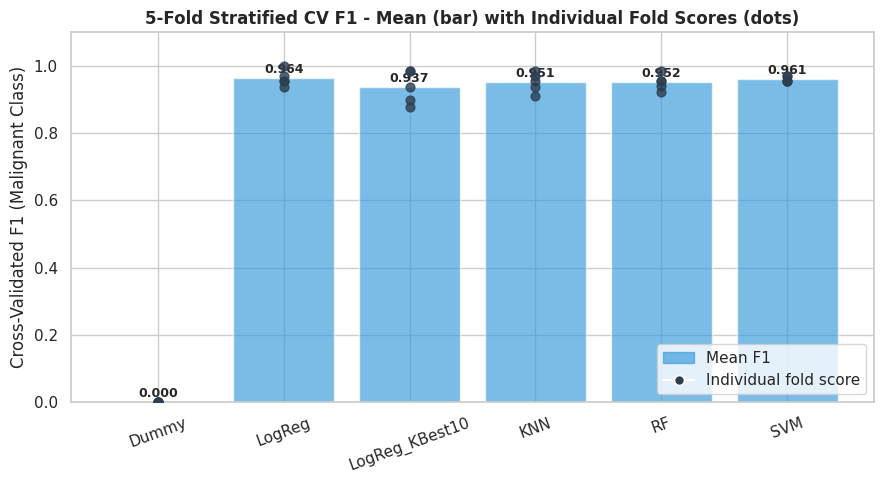

In [331]:
names = list(cv_results.keys())
means = [cv_results[n]['mean'] for n in names]
stds  = [cv_results[n]['std']  for n in names]

fig, ax = plt.subplots(figsize=(9, 5))

# Bar chart: mean CV F1
bars = ax.bar(names, means, color='#3498DB', alpha=0.65, edgecolor='white', label='Mean F1')

# Overlay individual fold scores as dots for each model
for i, name in enumerate(names):
    fold_scores = cv_results[name]['scores']
    ax.scatter(
        [i] * len(fold_scores), fold_scores,
        color='#2C3E50', zorder=5, s=40, alpha=0.8
    )

# Annotate mean value on each bar
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Cross-Validated F1 (Malignant Class)')
ax.set_title('5-Fold Stratified CV F1 - Mean (bar) with Individual Fold Scores (dots)',
             fontweight='bold')
ax.set_ylim(0, 1.10)
ax.tick_params(axis='x', rotation=20)

# Adding a legend to explain the bars and dots
from matplotlib.lines import Line2D
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color='#3498DB', alpha=0.65, label='Mean F1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2C3E50',
           markersize=7, label='Individual fold score'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**Model-comparison decision:** The full-feature Logistic Regression model is the strongest candidate after CV: it has the highest mean malignant F1 (0.9640) and a moderate fold-to-fold standard deviation (0.0207). SVM is nearly tied and more stable, so it must not be left as only a default-parameter comparator. I therefore tune SVM together with Logistic Regression and Random Forest. Random Forest is tuned because it is competitive and provides a useful non-linear feature-importance diagnostic. `LogReg_KBest10` is not selected for tuning because its selected-feature restriction lowers mean F1 and increases variance.

## 7. Hyperparameter Tuning

We tune the three serious candidate models using `GridSearchCV` with the same `StratifiedKFold(5)` strategy and `scoring='f1'` as the cross-validation comparison, ensuring comparability. Logistic Regression is tuned because it had the best mean CV F1. SVM is tuned because it was nearly tied with Logistic Regression and had the lowest CV variance among the strong models. Random Forest is tuned because it is competitive and provides a useful non-linear comparator.

`GridSearchCV` uses `n_jobs=1` for reproducibility and to avoid platform-specific nested-parallelism issues. The grids are deliberately small because this is a Basic ML project: the goal is not an exhaustive search, but a justified comparison of reasonable hyperparameter settings.

### 7.1 Logistic Regression Tuning

We search over regularisation strength `C` and penalty type (`l1` vs `l2`).

**Grid range justification:**
- `C = [0.001, 0.01, 0.1, 1, 10, 100]`: This logarithmic grid contains six candidate values and spans five orders of magnitude, from strong regularisation (`C = 0.001`) to weak regularisation (`C = 100`). Given the strong multicollinearity observed in Section 4.5, we expect a moderate `C` value to perform best - strong regularisation would shrink too aggressively across correlated features, while weak regularisation could produce unstable coefficients. The grid is intentionally wide to let the data reveal the optimal strength rather than pre-assuming it.
- `penalty = ['l1', 'l2']`: L2 (Ridge) is the standard choice under multicollinearity because it shrinks correlated coefficients toward each other rather than zeroing them out. L1 (Lasso) performs feature selection implicitly and may produce sparser solutions. Both are tested to let CV determine which is more effective for this dataset.
- `solver = 'liblinear'`: The only solver in this grid that supports both L1 and L2 reliably on datasets of this size without convergence issues.

In [332]:
param_grid_lr = {
    'clf__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear'],
}

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))
])

gs_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=1, refit=True
)
gs_lr.fit(X_train, y_train)

print('Best LR params:', gs_lr.best_params_)
print(f'Best CV F1 (LR): {gs_lr.best_score_:.4f}')

Best LR params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV F1 (LR): 0.9640


**Interpretation:** The best Logistic Regression configuration is `C = 1`, `penalty = 'l2'`, `solver = 'liblinear'`. This is a moderate regularisation setting, not an unregularised model. That choice is consistent with the multicollinearity observed in Section 4.5: L2 regularisation helps stabilise coefficients across strongly correlated radius/perimeter/area features while retaining all predictors.


### 7.2 Random Forest Tuning

We search over the number of trees (`n_estimators`) and maximum tree depth (`max_depth`).

**Grid range justification:**
- `n_estimators = [50, 100]`: With 569 total samples (455 in the training set after an 80/20 split), 50–100 trees are sufficient for variance reduction in the ensemble average. Adding more trees beyond ~100 rarely changes prediction quality significantly on datasets of this size, while increasing runtime proportionally. This range identifies whether the default 100 trees is already optimal or whether a smaller ensemble is equally competitive.
- `max_depth = [5, None]`: `max_depth = 5` limits each tree to at most 5 levels, producing at most 2⁵ = 32 leaf regions. This tests a moderately constrained forest against an unconstrained forest. An unconstrained tree (`None`) can grow until leaves are pure, which at this sample size may fit idiosyncratic training cases rather than stable morphology patterns. Testing both values lets cross-validation determine whether regularising tree depth is beneficial for this dataset.



In [333]:
param_grid_rf = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth':    [5, None],
}

pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])

gs_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=1, refit=True
)
gs_rf.fit(X_train, y_train)

print('Best RF params:', gs_rf.best_params_)
print(f'Best CV F1 (RF): {gs_rf.best_score_:.4f}')

Best RF params: {'clf__max_depth': 5, 'clf__n_estimators': 100}
Best CV F1 (RF): 0.9553


**What the best parameters reveal:** The best Random Forest configuration is `max_depth = 5` and `n_estimators = 100`. The finite depth is important: it shows that restricting tree complexity improves malignant-class F1 compared with fully grown trees in this focused grid. This is consistent with a small dataset where deep trees can fit idiosyncratic training cases rather than stable morphology patterns.


### 7.3 SVM Tuning

SVM was almost tied with Logistic Regression during cross-validation, so leaving it at default hyperparameters would make the final comparison methodologically weaker. I tune a compact RBF-SVM grid over `C` and `gamma`.

**Grid range justification:**
- `C = [0.1, 1, 10]`: controls the penalty for margin violations. Lower `C` allows a wider, smoother margin; higher `C` fits the training data more tightly. This range is enough to test underfitting vs. stronger boundary fitting without an excessive search.
- `gamma = ['scale', 0.01, 0.1]`: controls the RBF kernel width. `scale` is scikit-learn's data-dependent default; `0.01` tests a smoother boundary; `0.1` tests a more local boundary.
- `kernel = 'rbf'`: retained because the initial SVM comparator used RBF and because the goal is to test a non-linear margin-based model against Logistic Regression and Random Forest.

In [334]:
param_grid_svm = {
    'clf__C':     [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1],
    'clf__kernel': ['rbf'],
}

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=RANDOM_STATE, probability=True))
])

gs_svm = GridSearchCV(
    pipe_svm, param_grid_svm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=1, refit=True
)
gs_svm.fit(X_train, y_train)

print('Best SVM params:', gs_svm.best_params_)
print(f'Best CV F1 (SVM): {gs_svm.best_score_:.4f}')

Best SVM params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV F1 (SVM): 0.9674


**What the best parameters reveal:** The best SVM configuration is `C = 10`, `gamma = 'scale'`, and `kernel = 'rbf'`, with mean CV F1 = **0.9674**. This slightly exceeds the tuned Logistic Regression CV F1 (**0.9640**), so SVM is a legitimate competitor. However, the difference is only **0.0034 F1**, which is small relative to the fold-to-fold variation observed in cross-validation.

For that reason, the tuned SVM is carried forward to the held-out test evaluation, but it does not automatically replace Logistic Regression. Logistic Regression remains a strong final candidate because it is practically tied in validation performance, simpler, and more interpretable under the multicollinearity observed in Section 4.5.

## 8. Final Evaluation on the Test Set

We now evaluate the **three tuned candidate models** - Logistic Regression, Random Forest, and SVM - on the held-out test set. The test set has been untouched since the split in Section 5.2; these are its first and only use for model evaluation.

The summary table in Section 8.4 also reports the Dummy, KNN, and `LogReg_KBest10` comparators for context, but the final decision is made among the tuned candidate models.


In [335]:
def evaluate_model(fitted_model, X_test, y_test, model_name):
    """Print classification report and return prediction array"""
    y_pred = fitted_model.predict(X_test)
    print(f'=== {model_name} ===')
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
    return y_pred

def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a labelled confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign', 'Malignant'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

### 8.1 Logistic Regression (Tuned)

In [336]:
y_pred_lr = evaluate_model(gs_lr, X_test, y_test, 'Logistic Regression (Tuned)')

=== Logistic Regression (Tuned) ===
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Interpretation (Logistic Regression):** Logistic Regression achieves malignant precision = 0.98, recall = 0.95, and F1 = 0.96 on the held-out test set. In exact confusion-matrix terms, it misses 2 of 42 malignant cases and creates 1 false positive among 72 benign cases. Within this internal diagnostic-support framing, this is a strong error trade-off because the false-negative count is low while precision remains high.

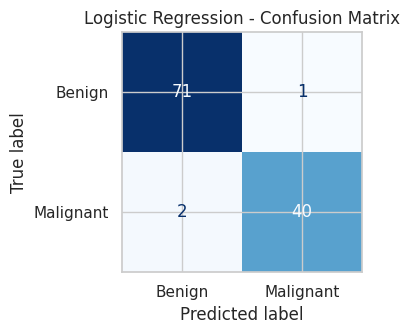

True Negatives  (Benign → Benign):     71
False Positives (Benign → Malignant):  1  [unnecessary follow-up]
False Negatives (Malignant → Benign):  2  [missed malignant case - highest diagnostic-support cost]
True Positives  (Malignant → Malignant): 40


In [337]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression - Confusion Matrix')

cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()
print(f'True Negatives  (Benign → Benign):     {tn}')
print(f'False Positives (Benign → Malignant):  {fp}  [unnecessary follow-up]')
print(f'False Negatives (Malignant → Benign):  {fn}  [missed malignant case - highest diagnostic-support cost]')
print(f'True Positives  (Malignant → Malignant): {tp}')

**Confusion matrix reading:** The four cells represent: **TN** (benign cases correctly classified), **FP** (benign cases incorrectly flagged as malignant), **FN** (malignant cases incorrectly predicted as benign), and **TP** (malignant cases correctly detected). In this project framing, FN is the highest-cost cell, so models with similar accuracy are compared by their malignant recall and false-negative count.

### 8.2 Random Forest (Tuned)

In [338]:
y_pred_rf = evaluate_model(gs_rf, X_test, y_test, 'Random Forest (Tuned)')

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



**Interpretation (Random Forest):** The confusion matrix printed below confirms the exact error counts. Random Forest produces **0 false positives** (no benign cases flagged as malignant) and **3 false negatives** (3 malignant cases incorrectly classified as benign). The TN/FP/FN/TP breakdown is printed explicitly in the cell output below.

Because this project treats false negatives as the highest-cost error in the diagnostic-support framing, Random Forest is not preferred over Logistic Regression despite its zero false-positive count. Logistic Regression misses only 2 malignant cases (vs 3 for Random Forest) while producing just 1 false positive. The trade-off of 1 additional false positive to avoid 1 false negative is favorable under this stated project objective.

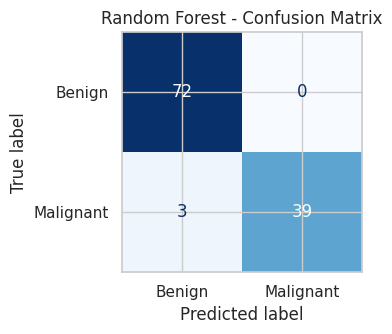

True Negatives  (Benign → Benign):     72
False Positives (Benign → Malignant):  0  [unnecessary follow-up]
False Negatives (Malignant → Benign):  3  [missed malignant case - highest diagnostic-support cost]
True Positives  (Malignant → Malignant): 39


In [339]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest - Confusion Matrix')

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
print(f'True Negatives  (Benign → Benign):     {tn}')
print(f'False Positives (Benign → Malignant):  {fp}  [unnecessary follow-up]')
print(f'False Negatives (Malignant → Benign):  {fn}  [missed malignant case - highest diagnostic-support cost]')
print(f'True Positives  (Malignant → Malignant): {tp}')

### 8.3 SVM (Tuned)

In [340]:
y_pred_svm = evaluate_model(gs_svm, X_test, y_test, 'SVM (Tuned)')

=== SVM (Tuned) ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



**Interpretation (SVM):** The tuned SVM is evaluated on the same untouched test set as Logistic Regression and Random Forest. This is not another hyperparameter-tuning step; it is a held-out comparison of already-tuned candidate models. Its exact confusion-matrix counts are inspected because overall accuracy alone can hide different false-negative profiles.

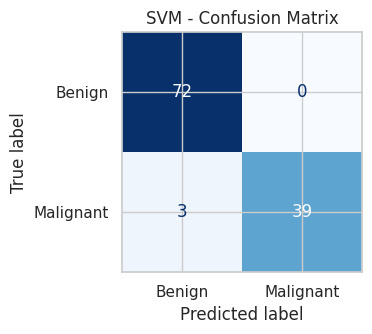

True Negatives  (Benign → Benign):       72
False Positives (Benign → Malignant):    0  [unnecessary follow-up]
False Negatives (Malignant → Benign):    3  [missed malignant case - highest diagnostic-support cost]
True Positives  (Malignant → Malignant): 39


In [341]:
plot_confusion_matrix(y_test, y_pred_svm, 'SVM - Confusion Matrix')

cm_svm = confusion_matrix(y_test, y_pred_svm)
tn, fp, fn, tp = cm_svm.ravel()
print(f'True Negatives  (Benign → Benign):       {tn}')
print(f'False Positives (Benign → Malignant):    {fp}  [unnecessary follow-up]')
print(f'False Negatives (Malignant → Benign):    {fn}  [missed malignant case - highest diagnostic-support cost]')
print(f'True Positives  (Malignant → Malignant): {tp}')

### 8.4 Summary Comparison Table

In [342]:
# Rebuild metrics cleanly using sklearn functions
def row_metrics(y_true, y_pred, y_score=None):
    row = {
        'Accuracy':      round(accuracy_score(y_true, y_pred), 4),
        'Precision (M)': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (M)':    round(recall_score(y_true, y_pred, pos_label=1), 4),
        'F1 (M)':        round(f1_score(y_true, y_pred, pos_label=1), 4),
    }
    if y_score is not None:
        row['ROC-AUC'] = round(roc_auc_score(y_true, y_score), 4)
    return row

# Fit comparator models on the full training set
# These are intentionally kept as default-parameter comparators, not final candidates
dummy_pipe  = pipelines['Dummy'].fit(X_train, y_train)
knn_pipe    = pipelines['KNN'].fit(X_train, y_train)
kbest_pipe  = pipelines['LogReg_KBest10'].fit(X_train, y_train)

prediction_map = {
    'Dummy (baseline)':          dummy_pipe.predict(X_test),
    'KNN (default)':             knn_pipe.predict(X_test),
    'LogReg_KBest10 (default)':  kbest_pipe.predict(X_test),
    'LogReg (tuned)':            y_pred_lr,
    'SVM (tuned)':               y_pred_svm,
    'RF (tuned)':                y_pred_rf,
}

score_map = {
    'Dummy (baseline)':          dummy_pipe.predict_proba(X_test)[:, 1],
    'KNN (default)':             knn_pipe.predict_proba(X_test)[:, 1],
    'LogReg_KBest10 (default)':  kbest_pipe.predict_proba(X_test)[:, 1],
    'LogReg (tuned)':            gs_lr.predict_proba(X_test)[:, 1],
    'SVM (tuned)':               gs_svm.predict_proba(X_test)[:, 1],
    'RF (tuned)':                gs_rf.predict_proba(X_test)[:, 1],
}

# Build the main metrics table
summary = pd.DataFrame({
    name: row_metrics(y_test, preds, score_map[name])
    for name, preds in prediction_map.items()
}).T.sort_values(['F1 (M)', 'Recall (M)', 'Precision (M)'], ascending=False)

# Add an explicit 'Tuned?' column so the comparison is transparent
summary.insert(0, 'Tuned?', [
    'Yes' if '(tuned)' in n else 'No'
    for n in summary.index
])

best_model_name = 'LogReg (tuned)'
best_preds = prediction_map[best_model_name]

print(summary.to_string())
print(f'\nFinal model: {best_model_name}')
summary

                         Tuned?  Accuracy  Precision (M)  Recall (M)  F1 (M)  ROC-AUC
LogReg (tuned)              Yes    0.9737         0.9756      0.9524  0.9639   0.9960
SVM (tuned)                 Yes    0.9737         1.0000      0.9286  0.9630   0.9927
RF (tuned)                  Yes    0.9737         1.0000      0.9286  0.9630   0.9950
KNN (default)                No    0.9561         0.9744      0.9048  0.9383   0.9823
LogReg_KBest10 (default)     No    0.9561         0.9744      0.9048  0.9383   0.9974
Dummy (baseline)             No    0.6316         0.0000      0.0000  0.0000   0.5000

Final model: LogReg (tuned)


,Tuned?,Accuracy,Precision (M),Recall (M),F1 (M),ROC-AUC
LogReg (tuned),Yes,0.9737,0.9756,0.9524,0.9639,0.9960
SVM (tuned),Yes,0.9737,1.0000,0.9286,0.9630,0.9927
RF (tuned),Yes,0.9737,1.0000,0.9286,0.9630,0.9950
KNN (default),No,0.9561,0.9744,0.9048,0.9383,0.9823
LogReg_KBest10 (default),No,0.9561,0.9744,0.9048,0.9383,0.9974
Dummy (baseline),No,0.6316,0.0000,0.0000,0.0000,0.5000


**Model selection and internal test-set assessment:** Logistic Regression is selected as the final model. The reason is not the test-set result alone: tuned SVM has only a marginal CV advantage over Logistic Regression (**0.9674** vs **0.9640**, a difference of **0.0034 F1**), while Logistic Regression is simpler, more interpretable, and directly compatible with the multicollinearity-aware L2 regularisation discussed earlier.

The held-out test set is then used to assess this final choice and compare candidate error profiles. On the test set, Logistic Regression has malignant F1 = **0.9639**, malignant recall = **0.9524**, and **2 false negatives**. Tuned SVM and tuned Random Forest both have malignant F1 = **0.9630**, malignant recall = **0.9286**, and **3 false negatives**.

The decision is therefore not based on accuracy alone: all three tuned models reach accuracy = **0.9737**, but their error profiles differ. Under the diagnostic-support framing, avoiding one additional false negative is more important than avoiding one false positive. Logistic Regression is also simpler and more interpretable than SVM, so it is the better final model unless SVM clearly improves validation performance or false-negative behavior, which it does not here.

One important detail is that `LogReg_KBest10` has a high ROC-AUC, but its default-threshold malignant F1 and recall are lower than the tuned Logistic Regression model. Because the stated objective is threshold-level diagnostic-support performance, not ranking performance alone, the selected-feature model is not chosen as the final model. Threshold optimization for such models is left as future work.

### 8.5 Precision-Recall and ROC Curves

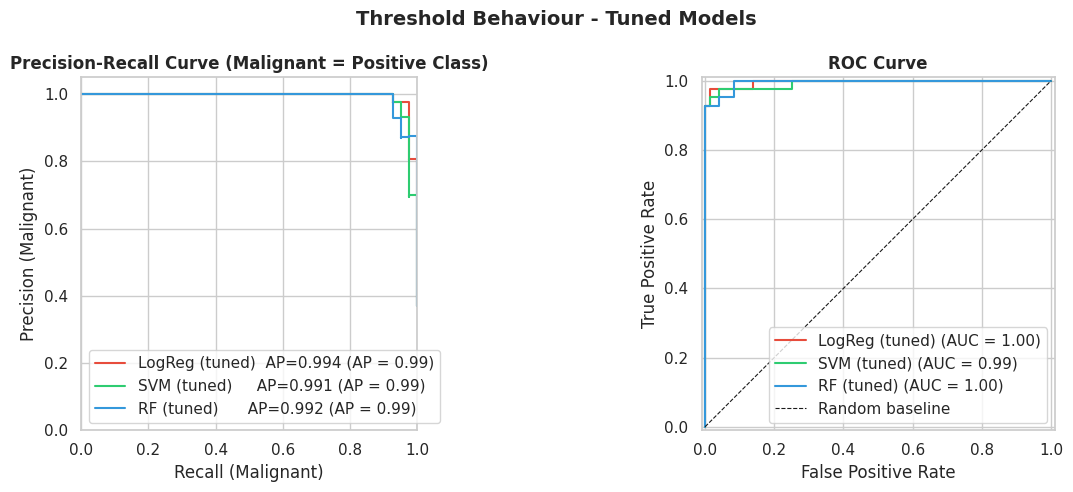

Average Precision (area under PR curve):
  LogReg (tuned): 0.9943
  SVM    (tuned): 0.9907
  RF     (tuned): 0.9923


In [343]:
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay, average_precision_score
)

lr_scores = gs_lr.predict_proba(X_test)[:, 1]
svm_scores = gs_svm.predict_proba(X_test)[:, 1]
rf_scores = gs_rf.predict_proba(X_test)[:, 1]

ap_lr = average_precision_score(y_test, lr_scores)
ap_svm = average_precision_score(y_test, svm_scores)
ap_rf = average_precision_score(y_test, rf_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall curves
PrecisionRecallDisplay.from_predictions(
    y_test, lr_scores, name=f'LogReg (tuned)  AP={ap_lr:.3f}',
    ax=axes[0], color='#E74C3C'
)
PrecisionRecallDisplay.from_predictions(
    y_test, svm_scores, name=f'SVM (tuned)     AP={ap_svm:.3f}',
    ax=axes[0], color='#2ECC71'
)
PrecisionRecallDisplay.from_predictions(
    y_test, rf_scores, name=f'RF (tuned)      AP={ap_rf:.3f}',
    ax=axes[0], color='#3498DB'
)
axes[0].set_title('Precision-Recall Curve (Malignant = Positive Class)',
                   fontweight='bold')
axes[0].set_xlabel('Recall (Malignant)')
axes[0].set_ylabel('Precision (Malignant)')
axes[0].legend(loc='lower left')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# ROC curves
RocCurveDisplay.from_predictions(
    y_test, lr_scores, name='LogReg (tuned)',
    ax=axes[1], color='#E74C3C'
)
RocCurveDisplay.from_predictions(
    y_test, svm_scores, name='SVM (tuned)',
    ax=axes[1], color='#2ECC71'
)
RocCurveDisplay.from_predictions(
    y_test, rf_scores, name='RF (tuned)',
    ax=axes[1], color='#3498DB'
)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.suptitle('Threshold Behaviour - Tuned Models', fontweight='heavy', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Average Precision (area under PR curve):')
print(f'  LogReg (tuned): {ap_lr:.4f}')
print(f'  SVM    (tuned): {ap_svm:.4f}')
print(f'  RF     (tuned): {ap_rf:.4f}')

**PR and ROC curve interpretation:** The Precision-Recall curve is the more relevant diagnostic here because it directly encodes the false-negative / false-positive trade-off for the minority malignant class. A high area under the PR curve (Average Precision) means the model maintains high precision as recall is pushed toward 1 - i.e., as it attempts to catch more malignant cases. The ROC curve complements this by showing the true-positive rate vs. false-positive rate trade-off across all thresholds; its area (ROC-AUC) is less sensitive to class imbalance but is widely reported and directly matches the summary table above.

The curves also show that threshold choice is a modelling decision, not a technical detail. Raising the decision threshold above 0.5 could improve malignant precision at the cost of recall, while lowering it below 0.5 would increase recall at the cost of additional false positives. Optimising the threshold explicitly under a diagnostic-support recall constraint is listed as a future-work item in Section 12.

## 9. Model Interpretation

The final predictive model is Logistic Regression, but I inspect both standardized Logistic Regression coefficients and Random Forest impurity importances. This gives two complementary views: the linear model explains the selected decision boundary, while Random Forest checks whether a non-linear model identifies the same morphology feature groups. Neither interpretation should be treated as causal evidence.

### 9.1 Random Forest Feature Importance


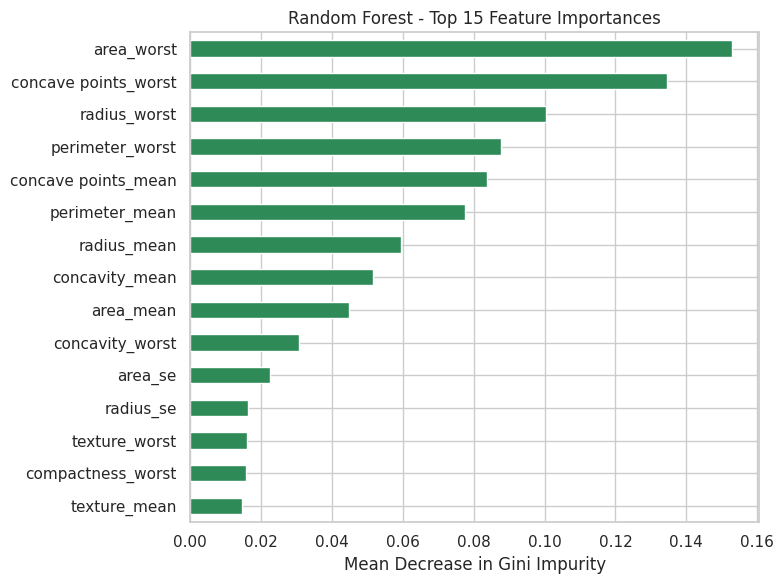

Top 5 features by RF importance:
area_worst              0.1529
concave points_worst    0.1345
radius_worst            0.1004
perimeter_worst         0.0876
concave points_mean     0.0837
dtype: float64


In [344]:
# Extract the fitted RF estimator from the tuned pipeline
rf_clf = gs_rf.best_estimator_.named_steps['clf']
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15[::-1].plot(kind='barh', ax=ax, color='seagreen', edgecolor='white')
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Random Forest - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print('Top 5 features by RF importance:')
print(top15.head(5).round(4))

**Cross-referencing with EDA:** Random Forest ranks `area_worst`, `concave points_worst`, `radius_worst`, `perimeter_worst`, and `concave points_mean` as its top five features. This broadly agrees with the EDA and target-correlation sections: the strongest signals are size and shape measurements, especially `_worst` values and concave-point measurements.

**Caveat on multicollinearity:** These rankings should be interpreted by feature group, not as a precise causal ordering of individual variables. Radius, perimeter, and area features are strongly correlated, so Random Forest can distribute importance across interchangeable predictors.


### 9.2 Logistic Regression Coefficients

Because Logistic Regression is the selected final model, its standardized coefficients are inspected as a direct model-specific interpretation. Coefficients are comparable because the model is trained after `StandardScaler`. However, due to multicollinearity, coefficient magnitude should still be interpreted cautiously: correlated variables can exchange weight without changing predictions much.


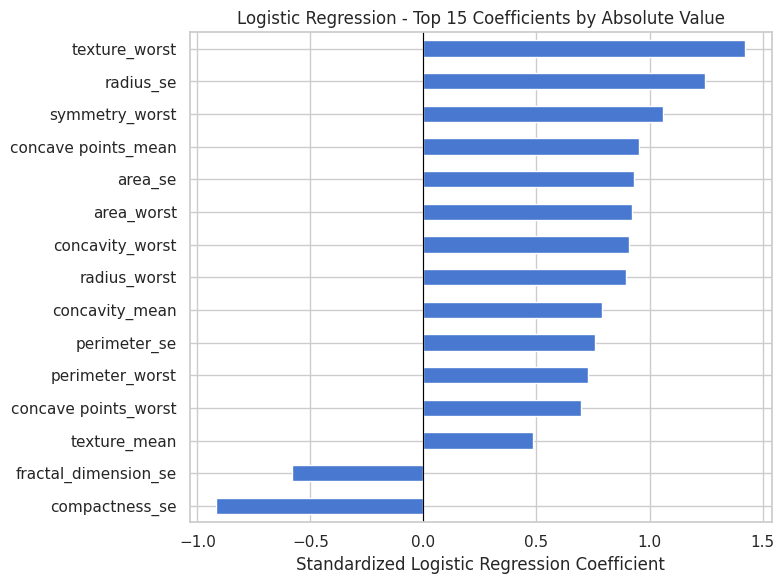

Top 10 standardized LR coefficients by absolute value:
texture_worst           1.4238
radius_se               1.2436
symmetry_worst          1.0591
concave points_mean     0.9548
area_se                 0.9334
area_worst              0.9241
compactness_se         -0.9158
concavity_worst         0.9106
radius_worst            0.8966
concavity_mean          0.7905
perimeter_se            0.7592
perimeter_worst         0.7261
concave points_worst    0.6979
fractal_dimension_se   -0.5813
texture_mean            0.4839


In [345]:
lr_clf = gs_lr.best_estimator_.named_steps['clf']
lr_coef = pd.Series(lr_clf.coef_[0], index=X.columns)
top_lr_coef = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).head(15).index)

fig, ax = plt.subplots(figsize=(8, 6))
top_lr_coef.sort_values().plot(kind='barh', ax=ax, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Logistic Regression Coefficient')
ax.set_title('Logistic Regression - Top 15 Coefficients by Absolute Value')
plt.tight_layout()
plt.show()

print('Top 10 standardized LR coefficients by absolute value:')
print(top_lr_coef.sort_values(key=abs, ascending=False).round(4).to_string())

**Coefficient interpretation:** The largest positive coefficients increase the predicted probability of malignancy, while negative coefficients decrease it. Because the model uses `StandardScaler`, coefficients are on a comparable scale - a larger absolute value indicates a stronger influence on the log-odds, holding all other features constant.

**Resolving the multicollinearity caveat with a concrete example:** The heatmap in Section 4.5 showed that `radius_mean`, `perimeter_mean`, and `area_mean` are correlated at ρ ≥ 0.98 (with `radius_mean`–`perimeter_mean` reaching ρ = 0.9979). Under L2 regularisation, Logistic Regression can distribute weight across correlated size-related variables rather than assigning all importance to a single one. In this fitted model, several size-related predictors appear among the large coefficients - for example `radius_se`, `area_se`, `area_worst`, `radius_worst`, `perimeter_se`, and `perimeter_worst` - while some near-duplicate mean features do not appear among the top coefficients individually.

The reliable conclusion is therefore at the **feature-group level**: the model relies heavily on size (radius/perimeter/area), shape (concave points, concavity), and their worst-case or variability-related versions. Individual coefficient rankings should not be over-interpreted as precise causal orderings of isolated variables.


## 10. Error Analysis

Understanding *which* cases the best model fails on is as important as knowing its overall metrics. Errors on the malignant class - false negatives - are the highest diagnostic-support cost failures and deserve dedicated investigation.

### 10.1 Identify Misclassified Samples

In [346]:
# Use the final selected model from the summary table
results = X_test.copy()
results['y_true'] = y_test.values
results['y_pred'] = best_preds

false_negatives = results[(results['y_true'] == 1) & (results['y_pred'] == 0)]
false_positives = results[(results['y_true'] == 0) & (results['y_pred'] == 1)]

print(f'Final selected model: {best_model_name}')
print(f'False Negatives (malignant predicted benign): {len(false_negatives)}')
print(f'False Positives (benign predicted malignant): {len(false_positives)}')

Final selected model: LogReg (tuned)
False Negatives (malignant predicted benign): 2
False Positives (benign predicted malignant): 1


### 10.2 Profile the False Negatives

The final Logistic Regression model has 2 false negatives. To understand this failure mode, I compare those missed malignant cases against correctly classified malignant cases using the top five Random Forest importance features. This is not a causal explanation, but it checks whether the missed cases have weaker values on the main morphology signals.


Feature profiles - False Negatives vs Correctly Classified Malignant:
                       FN mean    TP mean  All Malignant mean
area_worst            787.4000  1371.4350           1343.6238
concave points_worst    0.1578     0.1782              0.1772
radius_worst           16.1550    20.7642             20.5448
perimeter_worst       108.3500   138.3675            136.9381
concave points_mean     0.0584     0.0859              0.0846


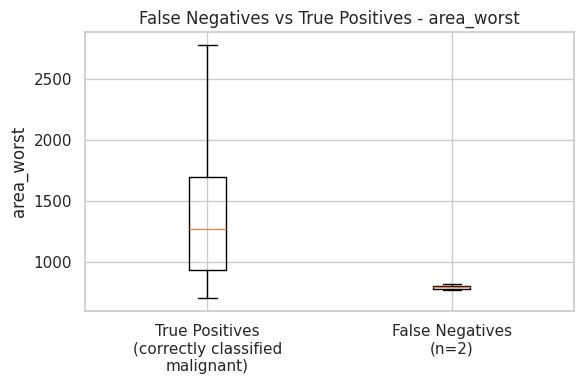

In [347]:
top5_feats = importances.sort_values(ascending=False).head(5).index.tolist()

# Correctly classified malignant test cases
true_positives = results[(results['y_true'] == 1) & (results['y_pred'] == 1)]

if len(false_negatives) > 0:
    fn_profile = false_negatives[top5_feats].mean().rename('FN mean')
    tp_profile = true_positives[top5_feats].mean().rename('TP mean')
    all_mal = results[results['y_true'] == 1][top5_feats].mean().rename('All Malignant mean')

    profile_df = pd.concat([fn_profile, tp_profile, all_mal], axis=1).round(4)
    print('Feature profiles - False Negatives vs Correctly Classified Malignant:')
    print(profile_df.to_string())

    # Overlay boxplot showing where FN samples fall on the most discriminative feature
    key_feat = top5_feats[0]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        [true_positives[key_feat].values, false_negatives[key_feat].values],
        labels=['True Positives\n(correctly classified\nmalignant)',
                f'False Negatives\n(n={len(false_negatives)})']
    )
    ax.set_ylabel(key_feat)
    ax.set_title(f'False Negatives vs True Positives - {key_feat}')
    plt.tight_layout()
    plt.show()
else:
    print('No false negatives on this test set - all malignant cases correctly identified.')

**Interpretation:** The false-negative malignant cases have much lower `area_worst`, `radius_worst`, `perimeter_worst`, and `concave points_mean` than correctly classified malignant cases. `concave points_worst` is also lower on average, but the gap is smaller than for size-related features. Therefore, the defensible interpretation is not simply "the model misses all low-concavity tumors"; rather, the missed malignant cases look closer to the benign range on several major size/shape features at the same time.

**This is the most important limitation of the final model:** it performs well on typical malignant morphology, but borderline malignant cases with less extreme morphology remain the main risk.


## 11. Conclusion

### Final Model

The final selected model is **tuned Logistic Regression**. It achieves:

- Accuracy = **0.9737**
- Malignant precision = **0.9756**
- Malignant recall = **0.9524**
- Malignant F1 = **0.9639**
- ROC-AUC = **0.9960**
- Confusion matrix errors: **2 false negatives** and **1 false positive**

The selection is based on the full evidence chain rather than a single number. Tuned SVM has the highest mean CV F1 (**0.9674**), but its advantage over tuned Logistic Regression (**0.9640**) is only **0.0034**, which is practically small relative to cross-validation variability. Logistic Regression is also simpler, more interpretable, and better aligned with the coefficient-level analysis in Section 9. On the held-out test set, this choice is not contradicted: Logistic Regression reaches the same accuracy as tuned SVM and tuned Random Forest (**0.9737**) while missing fewer malignant cases (**2 false negatives** instead of **3**).

### Evidence Synthesis

- **EDA:** The strongest class separation appears in size/shape features, especially concave-point, perimeter, radius, and area measurements.
- **Correlation analysis:** The top target-correlated features are `concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst`, and `perimeter_mean`.
- **Feature selection:** Training-only `SelectKBest` identifies the same feature family, but the selected-feature Logistic Regression model has lower malignant F1 and recall at the default threshold than the full-feature tuned Logistic Regression model. Therefore, feature selection is informative but not used in the final model.
- **Model comparison:** Full-feature Logistic Regression has the best untuned mean CV F1, while tuned SVM has the best tuned CV F1 by a very small margin. Because **the difference is practically small**, model simplicity and interpretability support Logistic Regression as the final model. The held-out test-set error profile is consistent with this choice because Logistic Regression has the highest malignant recall and the fewest false negatives.
- **Hyperparameter tuning:** The best LR model uses L2 regularisation with `C = 1`, consistent with the high multicollinearity observed in the feature set. SVM tuning is included because SVM was nearly tied in CV and should not be dismissed without testing `C` and `gamma`.
- **Error analysis:** The missed malignant cases have less extreme size/shape measurements than correctly classified malignant cases, so borderline morphology remains the main failure mode.

### Limitations

1. **Internal validation only:** The test set is a held-out split from the same WDBC cohort. It does not prove generalisation to other hospitals, imaging devices, or populations.
2. **Small dataset:** With 569 total samples and 42 malignant cases in the test set, each false negative changes recall noticeably. Reported performance should be interpreted with that sample-size limitation.
3. **Correlated features:** Radius, perimeter, and area features are strongly correlated. This supports regularisation but limits the interpretability of individual coefficients and impurity importances.
4. **Default threshold:** The final model uses the default 0.5 decision threshold. A diagnostic-support system should tune this threshold explicitly based on an acceptable false-negative rate.